In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats
from itertools import combinations
from xgboost import XGBRegressor
import re
#from pycaret.classification import setup, compare_models, create_model, tune_model, plot_model, evaluate_model, finalize_model, predict_model, save_model, load_model
import warnings
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split, GridSearchCV
warnings.filterwarnings("ignore")

In [2]:
len(np.arange(0.1,10.1,0.1))

100

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:
path = "C:/Users/Alber/OneDrive/Documentos/Métodos Supervisados USTA 2026/módulo 1/code 3/"

In [5]:
%%time
df = pd.read_csv(path  + 'train.csv')
prueba = pd.read_csv(path + "test.csv")


ct = ['Marital status',  
       'Displaced', 'Educational special needs','Gender' ]
       
for k in ct:
  df[k] = df[k].astype("O")
  #df[k] = "E" + df[k].astype(str)
  prueba[k] = prueba[k].astype("O")
  #prueba[k] = "E" + prueba[k].astype(str)  

CPU times: total: 391 ms
Wall time: 404 ms


In [6]:
prueba.get(ct).head(2)

,Marital status,Displaced,Educational special needs,Gender
0,E1,E1,E0,E0
1,E1,E1,E0,E0


In [7]:
prueba.head()

,id,Marital status,Course,Previous qualification,Mothers qualification,Fathers qualification,Admission grade,Displaced,Educational special needs,Gender,...,Curricular units 2nd sem credited,Curricular units 2nd sem enrolled,Curricular units 2nd sem evaluations,Curricular units 2nd sem approved,Curricular units 2nd sem grade,Curricular units 2nd sem without evaluations,Unemployment rate,Inflation rate,GDP,Target
0,1,E1,9238,1,19,19,119.8,E1,E0,E0,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,47.711099
1,3,E1,9500,1,19,3,126.1,E1,E0,E0,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,63.585995
2,5,E1,171,19,19,19,100.0,E0,E0,E1,...,0,0,0,0,0.000000,0,13.9,-0.3,0.79,41.091654
3,14,E1,9003,1,19,19,130.0,E0,E0,E1,...,0,6,8,0,0.000000,0,11.1,0.6,2.02,38.445493
4,26,E1,9773,1,1,19,134.5,E0,E0,E0,...,0,6,7,6,12.333333,0,16.2,0.3,-0.92,55.245917


In [8]:
df.shape

(61215, 27)

In [9]:
prueba.shape

(15303, 27)

## Train

In [10]:
ft = pd.DataFrame(df.isnull().sum()).reset_index()
ft.columns = ["Variable","Faltantes"]
ft["% Faltantes"] = ft["Faltantes"] * 100 / df.shape[0]
ft.loc[ft["% Faltantes"]>0]

,Variable,Faltantes,% Faltantes


In [11]:
formato = pd.DataFrame({'Variable': list(df.columns), 'Formato': df.dtypes })
ft = pd.merge(ft,formato,on=["Variable"],how="left")
ft.head()

,Variable,Faltantes,% Faltantes,Formato
0,id,0,0.0,int64
1,Marital status,0,0.0,object
2,Course,0,0.0,int64
3,Previous qualification,0,0.0,int64
4,Mothers qualification,0,0.0,int64


## 
Test

In [12]:
ft2 = pd.DataFrame(prueba.isnull().sum()).reset_index()
ft2.columns = ["Variable","Faltantes"]
ft2["% Faltantes"] = ft2["Faltantes"] * 100 / prueba.shape[0]
ft2.loc[ft2["% Faltantes"]>0]

,Variable,Faltantes,% Faltantes


## Análisis descriptivo

In [13]:
cuantitativas = list(formato.loc[formato["Formato"]!="object","Variable"])
cuantitativas = [x for x in cuantitativas if x not in ["id","Target"]]

cualitativas = list(formato.loc[formato["Formato"]=="object","Variable"])
cualitativas = [x for x in cuantitativas if x not in ["id","Target"]]

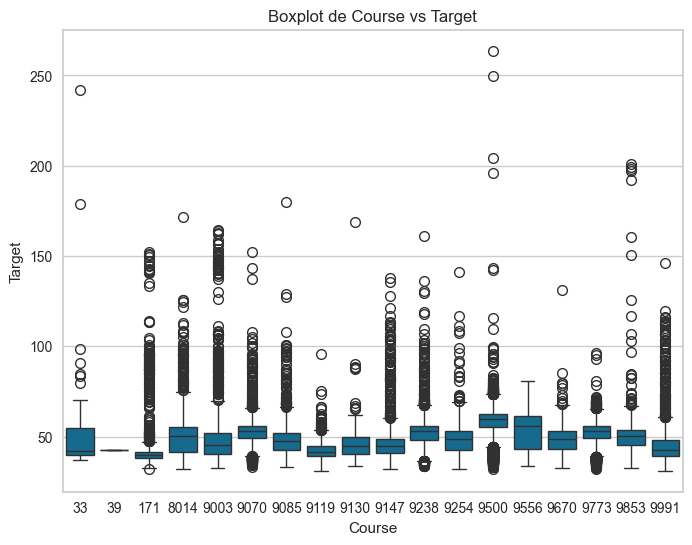

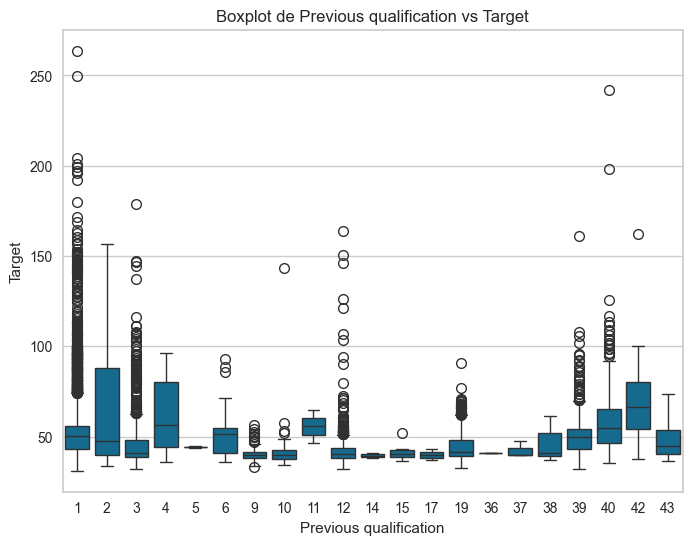

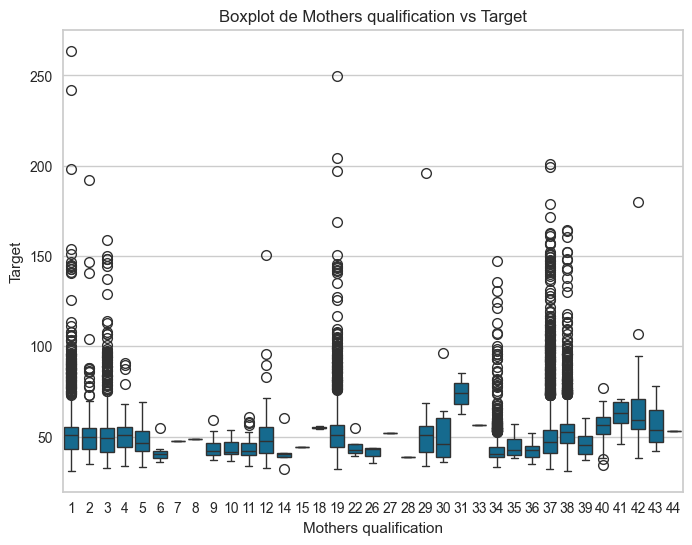

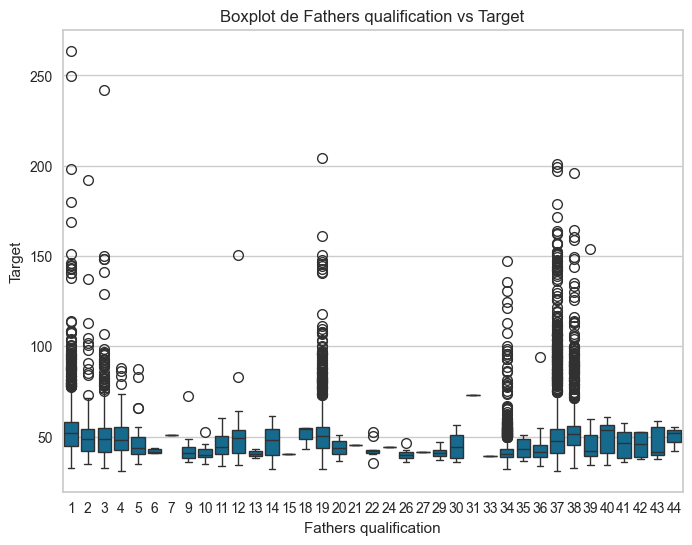

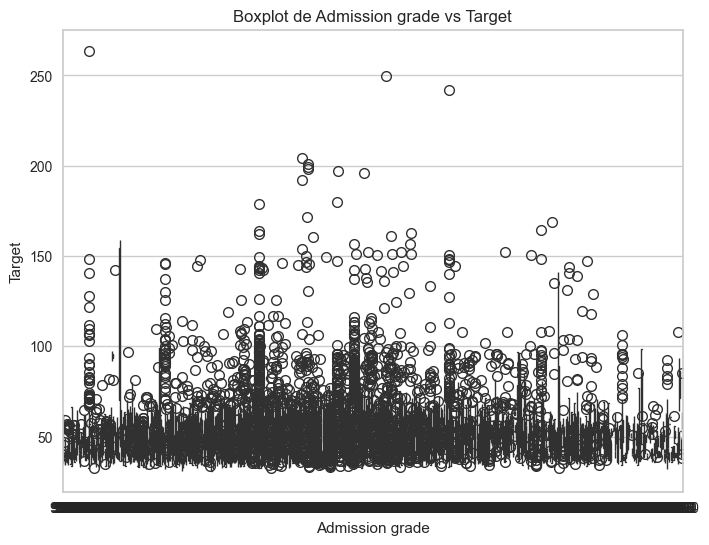

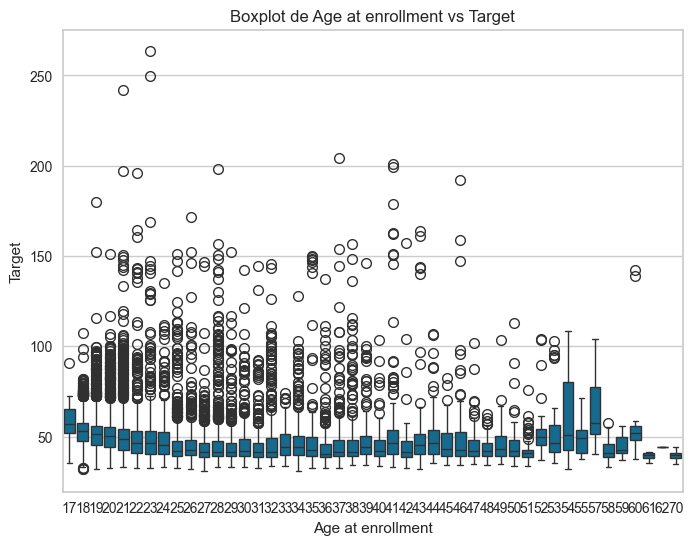

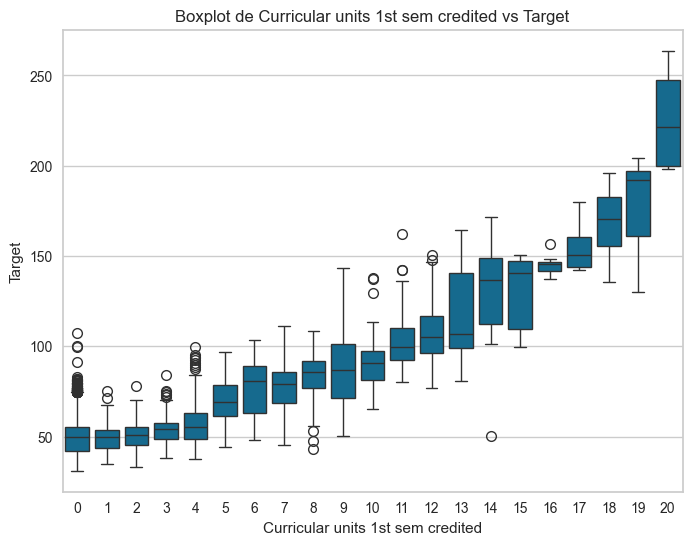

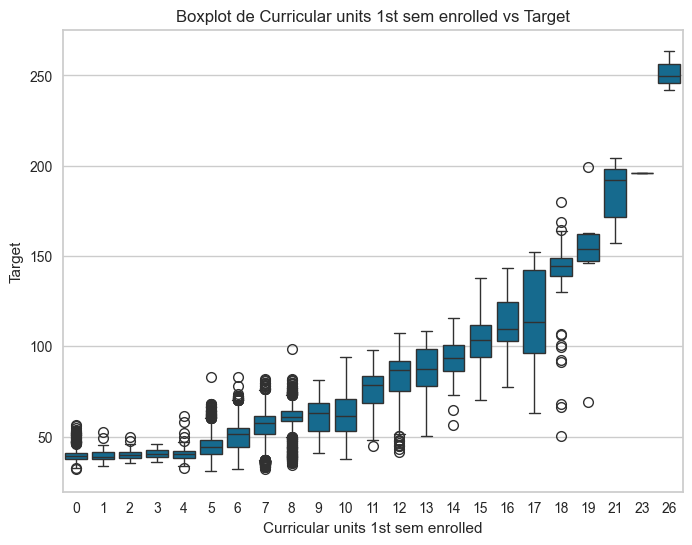

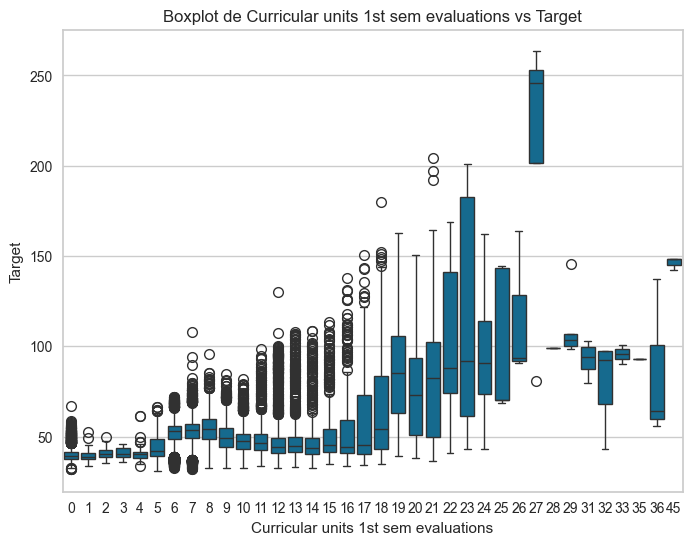

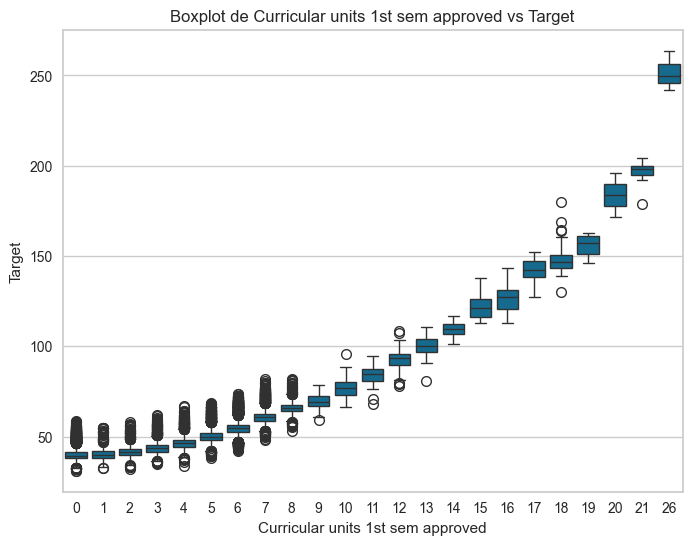

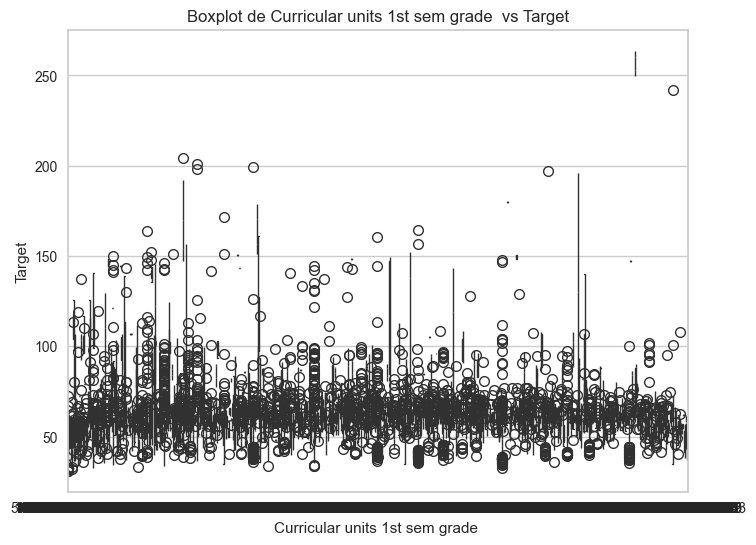

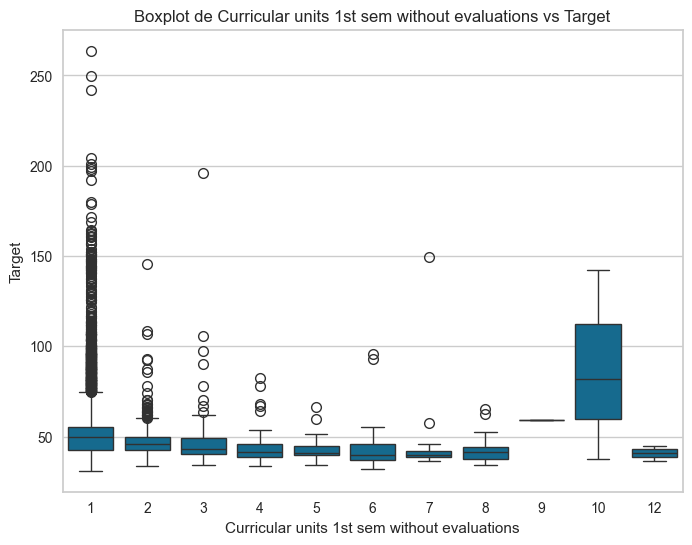

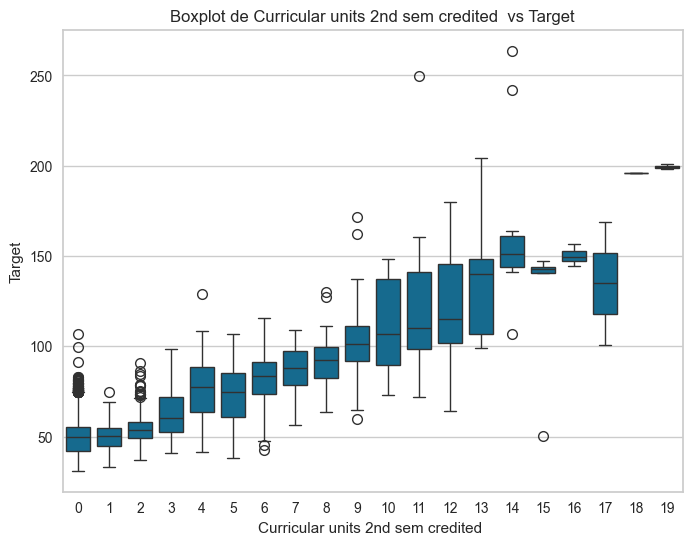

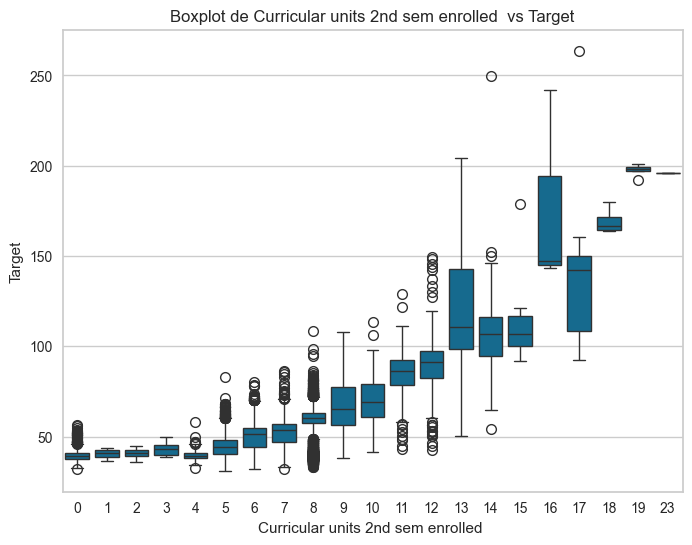

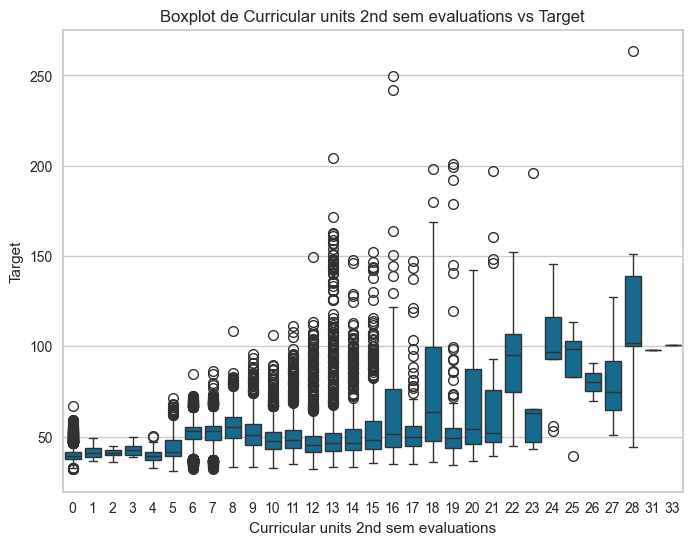

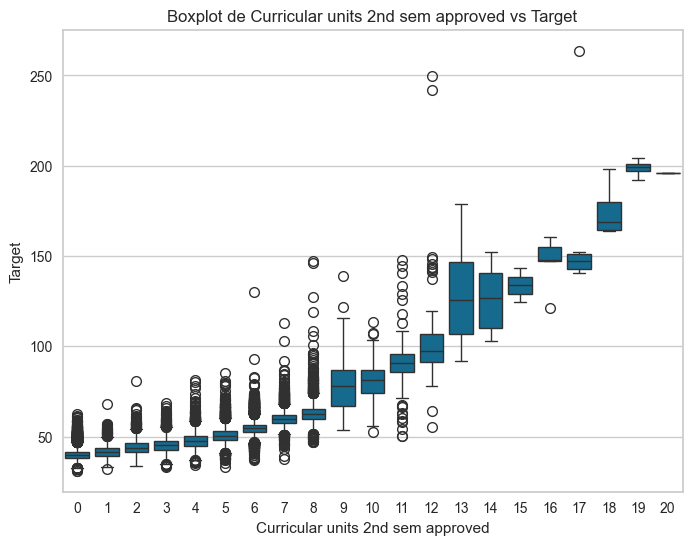

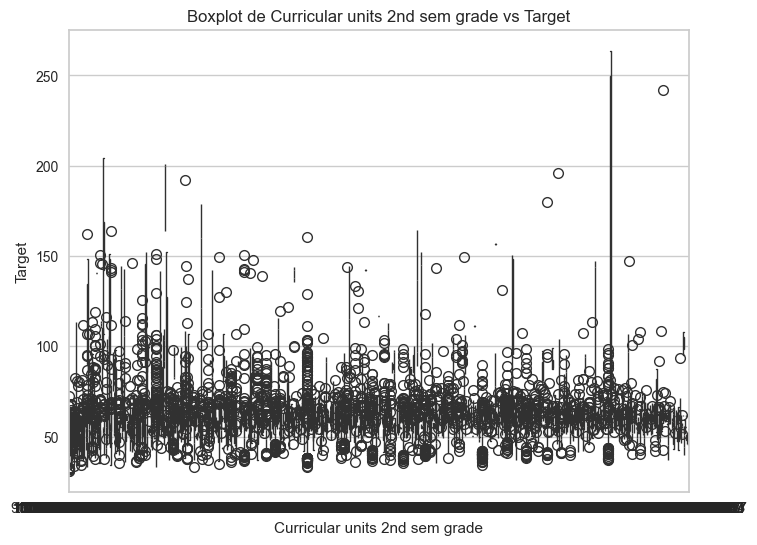

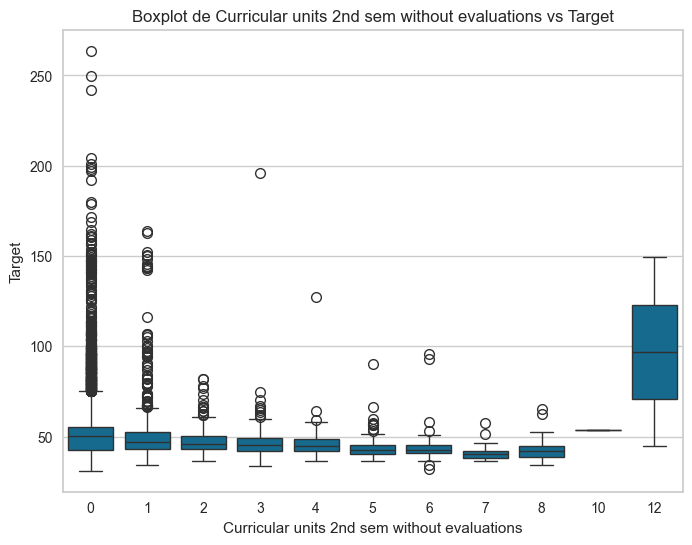

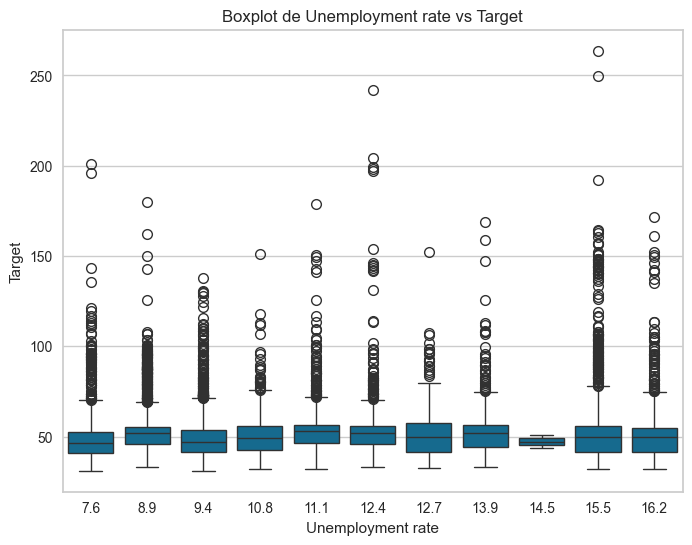

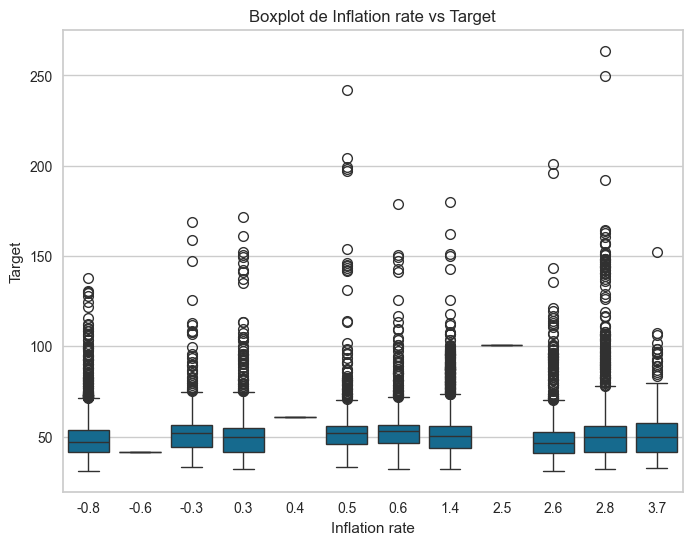

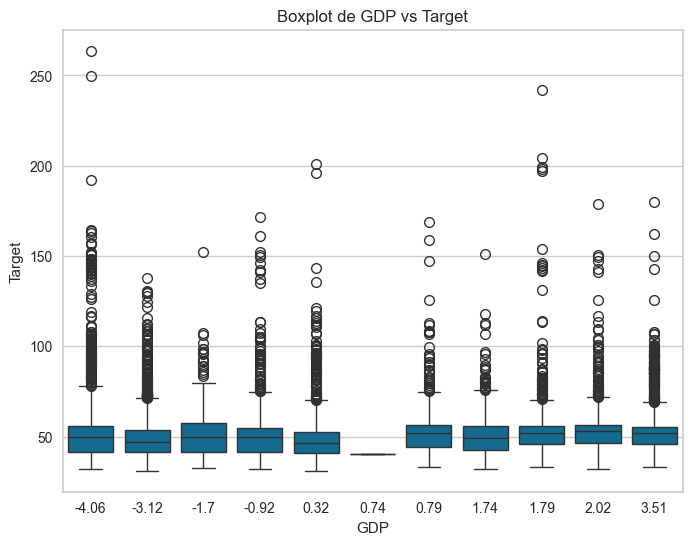

In [14]:
for k in cualitativas:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=k,y="Target",data=df)
    plt.title("Boxplot de "+k+" vs Target")

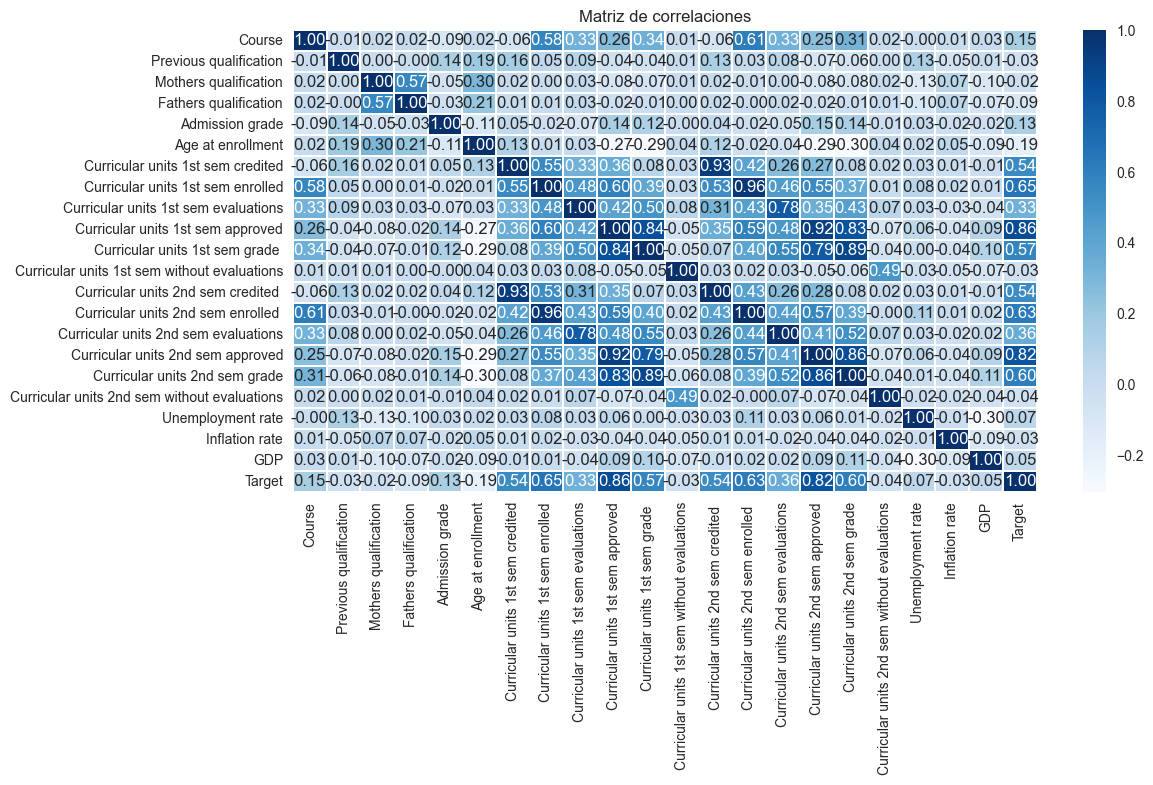

In [15]:
correlaciones = df.get(cuantitativas + ["Target"]).corr()
plt.figure(figsize=(12,6))
sns.heatmap(correlaciones, linewidths=0.01, cmap="Blues", annot=True, fmt=".2f")
plt.title("Matriz de correlaciones")
plt.show()

## Ingenierí­a de variables

### variables al cuadrado

In [16]:
df["Target"].describe()

count    61215.000000
mean        49.992325
std         10.002128
min         31.087248
25%         42.358811
50%         49.885835
75%         55.365990
max        263.648238
Name: Target, dtype: float64

In [17]:
base_cuadrado = df[cuantitativas].copy()
base_cuadrado["Target"] = df["Target"].copy()

var_names2, correlaciones = [], []

for k in cuantitativas:
    base_cuadrado[k + "_2"] = base_cuadrado[k] ** 2

    # Calcular correlaciÃƒÂ³n de la variable al cuadrado con Target
    corr = base_cuadrado[[k + "_2", "Target"]].corr().iloc[0, 1]
    
    # Guardar correlaciÃƒÂ³n y variable
    var_names2.append(k + "_2")
    correlaciones.append(np.round(corr, 2))

In [18]:
pcuadrado1 = pd.DataFrame({'Variable2':var_names2,'correlacion':correlaciones})
pcuadrado1['criterio'] = pcuadrado1['correlacion'].apply(lambda x: 1 if abs(x) > 0.5 else 0)
pcuadrado1.loc[pcuadrado1["criterio"]==1,].head(10)

,Variable2,correlacion,criterio
6,Curricular units 1st sem credited_2,0.56,1
7,Curricular units 1st sem enrolled_2,0.73,1
9,Curricular units 1st sem approved_2,0.94,1
10,Curricular units 1st sem grade _2,0.60,1
12,Curricular units 2nd sem credited _2,0.52,1
13,Curricular units 2nd sem enrolled _2,0.72,1
15,Curricular units 2nd sem approved_2,0.89,1
16,Curricular units 2nd sem grade_2,0.62,1


## Interacciones cuantitativas

In [19]:
lista_inter = list(combinations(cuantitativas,2))
base_interacciones = df.get(cuantitativas).copy()
base_interacciones["Target"] = df["Target"].copy()

var_interaccion, correlaciones = [], []
for k in lista_inter:
    col_name = k[0] + "__" + k[1]
    base_interacciones[col_name] = base_interacciones[k[0]] * base_interacciones[k[1]]

    corr = base_interacciones[[col_name, "Target"]].corr().iloc[0, 1]
    var_interaccion.append(col_name)
    correlaciones.append(np.round(corr, 2))

pxy = pd.DataFrame({'Variable':var_interaccion, 'correlacion':correlaciones})
pxy['criterio'] = pxy['correlacion'].apply(lambda x: 1 if abs(x) > 0.5 else 0)
pxy = pxy.sort_values('correlacion', ascending=False).reset_index(drop=True)
pxy.head()

,Variable,correlacion,criterio
0,Curricular units 1st sem approved__Curricular ...,0.94,1
1,Curricular units 1st sem approved__Curricular ...,0.93,1
2,Curricular units 1st sem enrolled__Curricular ...,0.92,1
3,Curricular units 1st sem enrolled__Curricular ...,0.92,1
4,Curricular units 2nd sem enrolled __Curricular...,0.90,1


In [20]:
list(pxy["Variable"])

['Curricular units 1st sem approved__Curricular units 2nd sem approved',
 'Curricular units 1st sem approved__Curricular units 2nd sem enrolled ',
 'Curricular units 1st sem enrolled__Curricular units 1st sem approved',
 'Curricular units 1st sem enrolled__Curricular units 2nd sem approved',
 'Curricular units 2nd sem enrolled __Curricular units 2nd sem approved',
 'Curricular units 1st sem approved__Curricular units 2nd sem grade',
 'Admission grade__Curricular units 1st sem approved',
 'Curricular units 1st sem approved__Curricular units 1st sem grade ',
 'Curricular units 1st sem approved__Curricular units 2nd sem evaluations',
 'Curricular units 1st sem evaluations__Curricular units 1st sem approved',
 'Curricular units 2nd sem evaluations__Curricular units 2nd sem approved',
 'Curricular units 1st sem evaluations__Curricular units 2nd sem approved',
 'Course__Curricular units 1st sem approved',
 'Curricular units 2nd sem approved__Curricular units 2nd sem grade',
 'Curricular unit

## Razones

In [21]:
raz1 = [(x, y) for x in cuantitativas for y in cuantitativas]
base_razones1 = df[cuantitativas].copy()
base_razones1["Target"] = df["Target"].copy()

var_nm, correlaciones = [], []
for j in raz1:
    if j[0] != j[1]:
        nombre_var = j[0] + "__coc__" + j[1]
        base_razones1[nombre_var] = base_razones1[j[0]] / (base_razones1[j[1]] + 0.01)

        corr = base_razones1[[nombre_var, "Target"]].corr().iloc[0, 1]

        var_nm.append(nombre_var)
        correlaciones.append(np.round(corr, 2))

In [22]:
prazones = pd.DataFrame({'Variable': var_nm, 'correlacion': correlaciones})
prazones['criterio'] = prazones['correlacion'].apply(lambda x: 1 if abs(x) > 0.5 else 0)
prazones_filtrado = prazones.iloc[(prazones['criterio'] == 1).to_numpy()]
prazones_filtrado.head()

,Variable,correlacion,criterio
88,Admission grade__coc__Curricular units 1st sem...,-0.52,1
89,Admission grade__coc__Curricular units 1st sem...,-0.52,1
94,Admission grade__coc__Curricular units 2nd sem...,-0.55,1
95,Admission grade__coc__Curricular units 2nd sem...,-0.55,1
114,Age at enrollment__coc__Curricular units 2nd s...,-0.53,1


## Interacciones categóricas

In [23]:
categoricas = list(formato.loc[formato["Formato"]=="O","Variable"])
categoricas = [x for x in categoricas if x not in ["id","Target"]]

def nombre_(x):
  return "C"+str(x)

categoricas

['Marital status', 'Displaced', 'Educational special needs', 'Gender']

In [24]:
cb = list(combinations(categoricas,2))
p_value, modalidades, nombre_var = [], [], []

base2 = df.get(categoricas).copy()
for k in base2.columns:
  base2[k] = base2[k].map(nombre_)

base2["Target"] = df["Target"].copy()

for k in range(len(cb)):
    # Variable con interacciÃƒÂ³n
    base2[cb[k][0]] = base2[cb[k][0]]
    base2[cb[k][1]] = base2[cb[k][1]]

    nombre_interaccion = cb[k][0] + "__" + cb[k][1]
    base2[nombre_interaccion] = base2[cb[k][0]] + "__" + base2[cb[k][1]]

    # Kruskal entre todas las combinaciones de modalidades
    mods = base2[nombre_interaccion].dropna().unique()
    pares_mods = list(combinations(mods, 2))
    pvals_mods = []

    for par in pares_mods:
        m1 = base2.loc[base2[nombre_interaccion] == par[0], "Target"].dropna().to_numpy()
        m2 = base2.loc[base2[nombre_interaccion] == par[1], "Target"].dropna().to_numpy()

        if len(m1) > 0 and len(m2) > 0:
            pv = stats.kruskal(m1, m2)[1]
            pvals_mods.append(pv)

    pv_min = np.min(pvals_mods) if len(pvals_mods) > 0 else np.nan

    # NÃƒÂºmero de modalidades por categorÃƒÂ­a
    mod_ = len(mods)

    # Guardar p value mÃƒÆ’Ã‚Â­nimo y modalidades
    nombre_var.append(nombre_interaccion)
    modalidades.append(mod_)
    p_value.append(pv_min)

In [25]:
pc = pd.DataFrame({'Variable':nombre_var,'Num Modalidades':modalidades,'p value':p_value})
pc.loc[(pc["p value"]<=0.20) & (pc["Num Modalidades"]<=15),].sort_values(["p value"],ascending=True).head()

,Variable,Num Modalidades,p value
2,Marital status__Gender,12,0.000000e+00
3,Displaced__Educational special needs,4,0.000000e+00
4,Displaced__Gender,4,0.000000e+00
5,Educational special needs__Gender,4,0.000000e+00
0,Marital status__Displaced,12,3.945330e-282


## Dummies categóricas más significativas (p value <= 0.20 y bajo número de modalidades)

In [26]:
def indicadora(x):
  if x==True:
    return 1
  else:
    return 0

seleccion1 = list(pc.loc[(pc["p value"]<=0.20) & (pc["Num Modalidades"]<=15),"Variable"])
sel1 = base2.get(seleccion1)

contador = 0
for k in sel1:
    if contador==0:
        lb1 = pd.get_dummies(sel1[k],drop_first=True)
        lb1.columns = [k + "_" + x for x in lb1.columns]
    else:
        lb2 = pd.get_dummies(sel1[k],drop_first=True)
        lb2.columns = [k + "_" + x for x in lb2.columns]
        lb1 = pd.concat([lb1,lb2],axis=1)
    contador = contador + 1

for k in lb1.columns:
  lb1[k] = lb1[k].map(indicadora)

lb1["Target"] = df["Target"].copy()
lb1.head(3)

,Marital status__Displaced_CE1__CE1,Marital status__Displaced_CE2__CE0,Marital status__Displaced_CE2__CE1,Marital status__Displaced_CE3__CE0,Marital status__Displaced_CE3__CE1,Marital status__Displaced_CE4__CE0,Marital status__Displaced_CE4__CE1,Marital status__Displaced_CE5__CE0,Marital status__Displaced_CE5__CE1,Marital status__Displaced_CE6__CE0,...,Displaced__Educational special needs_CE0__CE1,Displaced__Educational special needs_CE1__CE0,Displaced__Educational special needs_CE1__CE1,Displaced__Gender_CE0__CE1,Displaced__Gender_CE1__CE0,Displaced__Gender_CE1__CE1,Educational special needs__Gender_CE0__CE1,Educational special needs__Gender_CE1__CE0,Educational special needs__Gender_CE1__CE1,Target
0,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,47.695136
1,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,53.464861
2,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,60.708171


## Interacción cuantitativa vs categórica

In [27]:
cat_cuanti = [(x,y) for x in cuantitativas for y in categoricas]
cat_cuanti[0]

('Course', 'Marital status')

In [28]:
v1, v2, correlaciones_max = [], [], []

for j in cat_cuanti:
    k1 = j[0]
    k2 = j[1]

    g1 = pd.get_dummies(df[k2])
    lt1 = list(g1.columns)

    for k in lt1:
        g1[k] = g1[k] * df[k1]

    g1["Target"] = df["Target"].copy()

    correlaciones_c = []
    for y in lt1:
        corr = g1[[y, "Target"]].corr().iloc[0, 1]
        correlaciones_c.append(np.round(corr, 2))

    max_ = np.max(np.abs(correlaciones_c)) # Se calcula la maxima correlacion absoluta por categoria
    v1.append(k1)
    v2.append(k2)
    correlaciones_max.append(np.round(max_,2))

In [29]:
pc2 = pd.DataFrame({'Cuantitativa': v1, 'CategÃ³rica': v2, 'correlacion': correlaciones_max})
pc2.loc[np.abs(pc2["correlacion"]) > 0.5,]

,Cuantitativa,CategÃ³rica,correlacion
26,Curricular units 1st sem credited,Educational special needs,0.54
30,Curricular units 1st sem enrolled,Educational special needs,0.64
31,Curricular units 1st sem enrolled,Gender,0.51
36,Curricular units 1st sem approved,Marital status,0.77
38,Curricular units 1st sem approved,Educational special needs,0.86
39,Curricular units 1st sem approved,Gender,0.71
40,Curricular units 1st sem grade,Marital status,0.52
42,Curricular units 1st sem grade,Educational special needs,0.57
43,Curricular units 1st sem grade,Gender,0.53
50,Curricular units 2nd sem credited,Educational special needs,0.54


## Base de Feature Enginnering

In [30]:
v1 = list(pc2.loc[np.abs(pc2["correlacion"]) > 0.5, "Cuantitativa"])
v2 = list(pc2.loc[np.abs(pc2["correlacion"]) > 0.5, "CategÃ³rica"])

In [31]:
for j in range(len(v1)):

    if j==0:
        g1 = pd.get_dummies(df[v2[j]],drop_first=True)
        lt1 = list(g1.columns)
        for k in lt1:
            g1[k] = g1[k] * df[v1[j]]
        g1.columns = [v1[j] + "_" + v2[j] + "_" + str(x) for x in lt1]
    else:
        g2 = pd.get_dummies(df[v2[j]],drop_first=True)
        lt1 = list(g2.columns)
        for k in lt1:
            g2[k] = g2[k] * df[v1[j]]
        g2.columns = [v1[j] + "_" + v2[j] + "_" + str(x) for x in lt1]
        g1 = pd.concat([g1,g2],axis=1)

g1["Target"] = df["Target"].copy()
g1.head(5)

,Curricular units 1st sem credited_Educational special needs_E1,Curricular units 1st sem enrolled_Educational special needs_E1,Curricular units 1st sem enrolled_Gender_E1,Curricular units 1st sem approved_Marital status_E2,Curricular units 1st sem approved_Marital status_E3,Curricular units 1st sem approved_Marital status_E4,Curricular units 1st sem approved_Marital status_E5,Curricular units 1st sem approved_Marital status_E6,Curricular units 1st sem approved_Educational special needs_E1,Curricular units 1st sem approved_Gender_E1,...,Curricular units 2nd sem approved_Educational special needs_E1,Curricular units 2nd sem approved_Gender_E1,Curricular units 2nd sem grade_Marital status_E2,Curricular units 2nd sem grade_Marital status_E3,Curricular units 2nd sem grade_Marital status_E4,Curricular units 2nd sem grade_Marital status_E5,Curricular units 2nd sem grade_Marital status_E6,Curricular units 2nd sem grade_Educational special needs_E1,Curricular units 2nd sem grade_Gender_E1,Target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,47.695136
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,53.464861
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,60.708171
3,0,0,17,17,0,0,0,0,0,17,...,0,17,14.888889,0.0,0.0,0.0,0.0,0.0,14.888889,143.994593
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,62.017349


## Selección de variables con XGBOOST

### variables al cuadrado

In [32]:
pcuadrado1.head()

,Variable2,correlacion,criterio
0,Course_2,0.15,0
1,Previous qualification_2,0.01,0
2,Mothers qualification_2,-0.02,0
3,Fathers qualification_2,-0.08,0
4,Admission grade_2,0.12,0


In [33]:
var_cuad = list(pcuadrado1["Variable2"])
base_modelo1 = base_cuadrado.get(var_cuad+["Target"])
base_modelo1.head()

,Course_2,Previous qualification_2,Mothers qualification_2,Fathers qualification_2,Admission grade_2,Age at enrollment_2,Curricular units 1st sem credited_2,Curricular units 1st sem enrolled_2,Curricular units 1st sem evaluations_2,Curricular units 1st sem approved_2,...,Curricular units 2nd sem credited _2,Curricular units 2nd sem enrolled _2,Curricular units 2nd sem evaluations_2,Curricular units 2nd sem approved_2,Curricular units 2nd sem grade_2,Curricular units 2nd sem without evaluations_2,Unemployment rate_2,Inflation rate_2,GDP_2,Target
0,82537225,1521,1,1,22500.00,484,0,25,36,25,...,0,25,25,25,184.960000,0,262.44,0.09,0.8464,47.695136
1,81054009,1521,9,361,19600.00,361,0,36,81,36,...,0,36,49,36,176.510204,0,153.76,0.25,3.2041,53.464861
2,90250000,1,1444,1369,17397.61,361,0,49,64,49,...,0,64,64,64,228.010000,0,240.25,7.84,16.4836,60.708171
3,81054009,1,361,1369,23409.00,441,225,289,324,289,...,225,169,169,289,221.679012,0,240.25,7.84,16.4836,143.994593
4,90250000,1600,1,1,36100.00,676,0,49,49,49,...,1,64,81,64,209.606049,0,240.25,7.84,16.4836,62.017349


In [34]:
cov = list(base_modelo1.columns)
cov = [x for x in cov if x not in ["Target"]]

X1 = base_modelo1.get(cov)
y1 = base_modelo1.get(["Target"])

modelo1 = XGBRegressor()
modelo1 = modelo1.fit(X1,y1)

importancias = modelo1.feature_importances_
imp1 = pd.DataFrame({'Variable':X1.columns,'Importancia':importancias})
imp1["Importancia"] = imp1["Importancia"] * 100 / np.sum(imp1["Importancia"])
imp1 = imp1.sort_values(["Importancia"],ascending=False)
imp1.index = range(imp1.shape[0])
imp1.head()

,Variable,Importancia
0,Curricular units 1st sem approved_2,91.787987
1,Curricular units 2nd sem approved_2,3.265546
2,Fathers qualification_2,1.833007
3,Mothers qualification_2,1.565873
4,Curricular units 1st sem enrolled_2,0.546208


## Interacciones cuantitativas

In [35]:
pxy.head()

,Variable,correlacion,criterio
0,Curricular units 1st sem approved__Curricular ...,0.94,1
1,Curricular units 1st sem approved__Curricular ...,0.93,1
2,Curricular units 1st sem enrolled__Curricular ...,0.92,1
3,Curricular units 1st sem enrolled__Curricular ...,0.92,1
4,Curricular units 2nd sem enrolled __Curricular...,0.90,1


In [36]:
pxy["criterio"].value_counts()

criterio
0    132
1     78
Name: count, dtype: int64

In [37]:
var_int = list(pxy["Variable"])
base_modelo2 = base_interacciones.get(var_int+["Target"])
base_modelo2.head()

,Curricular units 1st sem approved__Curricular units 2nd sem approved,Curricular units 1st sem approved__Curricular units 2nd sem enrolled,Curricular units 1st sem enrolled__Curricular units 1st sem approved,Curricular units 1st sem enrolled__Curricular units 2nd sem approved,Curricular units 2nd sem enrolled __Curricular units 2nd sem approved,Curricular units 1st sem approved__Curricular units 2nd sem grade,Admission grade__Curricular units 1st sem approved,Curricular units 1st sem approved__Curricular units 1st sem grade,Curricular units 1st sem approved__Curricular units 2nd sem evaluations,Curricular units 1st sem evaluations__Curricular units 1st sem approved,...,Mothers qualification__Fathers qualification,Mothers qualification__Age at enrollment,Course__Age at enrollment,Age at enrollment__Unemployment rate,Curricular units 1st sem credited__GDP,Age at enrollment__Curricular units 1st sem without evaluations,Curricular units 2nd sem credited __GDP,Admission grade__Age at enrollment,Fathers qualification__Age at enrollment,Target
0,25,25,25,25,25,68.000000,750.0,72.500000,25,30,...,1,22,199870,356.4,-0.0,22,-0.00,3300.0,22,47.695136
1,36,36,36,36,36,79.714286,840.0,75.000000,42,54,...,57,57,171057,235.6,0.0,19,0.00,2660.0,361,53.464861
2,56,56,49,56,64,105.700000,923.3,98.350000,56,56,...,1406,722,180500,294.5,-0.0,19,-0.00,2506.1,703,60.708171
3,289,221,289,289,221,253.111111,2601.0,227.611111,221,306,...,703,399,189063,325.5,-60.9,21,-60.90,3213.0,777,143.994593
4,56,56,49,56,64,101.344444,1330.0,96.300000,63,49,...,1,26,247000,403.0,-0.0,26,-4.06,4940.0,26,62.017349


In [38]:
cov = list(base_modelo2.columns)
cov = [x for x in cov if x not in ["Target"]]

X2 = base_modelo2.get(cov)
y2 = base_modelo2.get(["Target"])

modelo2 = XGBRegressor()
modelo2 = modelo2.fit(X2,y2)

importancias = modelo2.feature_importances_
imp2 = pd.DataFrame({'Variable':X2.columns,'Importancia':importancias})
imp2["Importancia"] = imp2["Importancia"] * 100 / np.sum(imp2["Importancia"])
imp2 = imp2.sort_values(["Importancia"],ascending=False)
imp2.index = range(imp2.shape[0])
imp2.head()

,Variable,Importancia
0,Curricular units 1st sem approved__Curricular ...,26.969595
1,Curricular units 1st sem enrolled__Curricular ...,24.606005
2,Curricular units 1st sem approved__Curricular ...,7.193231
3,Curricular units 1st sem credited__Curricular ...,7.035239
4,Curricular units 1st sem approved__Curricular ...,6.962333


### Razones

In [39]:
prazones.head()

,Variable,correlacion,criterio
0,Course__coc__Previous qualification,0.17,0
1,Course__coc__Mothers qualification,0.03,0
2,Course__coc__Fathers qualification,0.13,0
3,Course__coc__Admission grade,0.06,0
4,Course__coc__Age at enrollment,0.28,0


In [40]:
var_raz = list(prazones["Variable"])
base_modelo3 = base_razones1.get(var_raz+["Target"])
base_modelo3.head()

,Course__coc__Previous qualification,Course__coc__Mothers qualification,Course__coc__Fathers qualification,Course__coc__Admission grade,Course__coc__Age at enrollment,Course__coc__Curricular units 1st sem credited,Course__coc__Curricular units 1st sem enrolled,Course__coc__Curricular units 1st sem evaluations,Course__coc__Curricular units 1st sem approved,Course__coc__Curricular units 1st sem grade,...,GDP__coc__Curricular units 1st sem without evaluations,GDP__coc__Curricular units 2nd sem credited,GDP__coc__Curricular units 2nd sem enrolled,GDP__coc__Curricular units 2nd sem evaluations,GDP__coc__Curricular units 2nd sem approved,GDP__coc__Curricular units 2nd sem grade,GDP__coc__Curricular units 2nd sem without evaluations,GDP__coc__Unemployment rate,GDP__coc__Inflation rate,Target
0,232.889003,8995.049505,8995.049505,60.562629,412.766924,908500.000000,1813.373253,1511.647255,1813.373253,626.119917,...,-0.910891,-92.000000,-0.183633,-0.183633,-0.183633,-0.067597,-92.0,-0.056755,-2.967742,47.695136
1,230.786978,2991.029900,473.592846,64.302550,473.592846,900300.000000,1498.003328,999.223085,1498.003328,719.664269,...,1.772277,179.000000,0.297837,0.255350,0.297837,0.134630,179.0,0.144239,3.509804,53.464861
2,9405.940594,249.934228,256.687382,72.018801,499.736981,950000.000000,1355.206847,1186.017478,1355.206847,675.675676,...,-4.019802,-406.000000,-0.506866,-0.506866,-0.506866,-0.268696,-406.0,-0.261767,-1.444840,60.708171
3,8913.861386,473.592846,243.258579,58.839292,428.510233,599.800133,529.276896,499.888951,529.276896,671.921387,...,-4.019802,-0.270486,-0.312068,-0.312068,-0.238683,-0.272504,-406.0,-0.261767,-1.444840,143.994593
4,237.440640,9405.940594,9405.940594,49.997369,365.244137,950000.000000,1355.206847,1355.206847,1355.206847,690.048770,...,-4.019802,-4.019802,-0.506866,-0.450610,-0.506866,-0.280236,-406.0,-0.261767,-1.444840,62.017349


In [41]:
cov = list(base_modelo3.columns)
cov = [x for x in cov if x not in ["Target"]]

X3 = base_modelo3.get(cov)
y3 = base_modelo3.get(["Target"])

modelo3 = XGBRegressor()
modelo3 = modelo3.fit(X3,y3)

importancias = modelo3.feature_importances_
imp3 = pd.DataFrame({'Variable':X3.columns,'Importancia':importancias})
imp3["Importancia"] = imp3["Importancia"] * 100 / np.sum(imp3["Importancia"])
imp3 = imp3.sort_values(["Importancia"],ascending=False)
imp3.index = range(imp3.shape[0])
imp3.head()

,Variable,Importancia
0,Course__coc__Curricular units 1st sem approved,34.287708
1,Curricular units 1st sem approved__coc__Curric...,30.525751
2,Curricular units 2nd sem approved__coc__Curric...,11.196277
3,Curricular units 1st sem approved__coc__Course,8.284517
4,Curricular units 1st sem credited__coc__Curric...,1.220198


## Interacciones categóricas

In [42]:
pc.head()

,Variable,Num Modalidades,p value
0,Marital status__Displaced,12,3.945330e-282
1,Marital status__Educational special needs,9,1.480856e-196
2,Marital status__Gender,12,0.000000e+00
3,Displaced__Educational special needs,4,0.000000e+00
4,Displaced__Gender,4,0.000000e+00


In [43]:
lb1.head()

,Marital status__Displaced_CE1__CE1,Marital status__Displaced_CE2__CE0,Marital status__Displaced_CE2__CE1,Marital status__Displaced_CE3__CE0,Marital status__Displaced_CE3__CE1,Marital status__Displaced_CE4__CE0,Marital status__Displaced_CE4__CE1,Marital status__Displaced_CE5__CE0,Marital status__Displaced_CE5__CE1,Marital status__Displaced_CE6__CE0,...,Displaced__Educational special needs_CE0__CE1,Displaced__Educational special needs_CE1__CE0,Displaced__Educational special needs_CE1__CE1,Displaced__Gender_CE0__CE1,Displaced__Gender_CE1__CE0,Displaced__Gender_CE1__CE1,Educational special needs__Gender_CE0__CE1,Educational special needs__Gender_CE1__CE0,Educational special needs__Gender_CE1__CE1,Target
0,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,47.695136
1,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,53.464861
2,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,60.708171
3,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,1,1,0,0,143.994593
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,62.017349


In [44]:
cov = list(lb1.columns)
cov = [x for x in cov if x not in ["Target"]]

X4 = lb1.get(cov)
y4 = lb1.get(["Target"])

modelo4 = XGBRegressor()
modelo4 = modelo4.fit(X4,y4)

importancias = modelo4.feature_importances_
imp4 = pd.DataFrame({'Variable':X4.columns,'Importancia':importancias})
imp4["Importancia"] = imp4["Importancia"] * 100 / np.sum(imp4["Importancia"])
imp4 = imp4.sort_values(["Importancia"],ascending=False)
imp4.index = range(imp4.shape[0])
imp4.head(5)

,Variable,Importancia
0,Educational special needs__Gender_CE0__CE1,91.810707
1,Marital status__Displaced_CE1__CE1,2.942560
2,Marital status__Educational special needs_CE4_...,2.029421
3,Marital status__Educational special needs_CE2_...,1.791409
4,Displaced__Educational special needs_CE1__CE0,0.407572


## Interacción cuantitativa - categórica

In [45]:
g1.head()

,Curricular units 1st sem credited_Educational special needs_E1,Curricular units 1st sem enrolled_Educational special needs_E1,Curricular units 1st sem enrolled_Gender_E1,Curricular units 1st sem approved_Marital status_E2,Curricular units 1st sem approved_Marital status_E3,Curricular units 1st sem approved_Marital status_E4,Curricular units 1st sem approved_Marital status_E5,Curricular units 1st sem approved_Marital status_E6,Curricular units 1st sem approved_Educational special needs_E1,Curricular units 1st sem approved_Gender_E1,...,Curricular units 2nd sem approved_Educational special needs_E1,Curricular units 2nd sem approved_Gender_E1,Curricular units 2nd sem grade_Marital status_E2,Curricular units 2nd sem grade_Marital status_E3,Curricular units 2nd sem grade_Marital status_E4,Curricular units 2nd sem grade_Marital status_E5,Curricular units 2nd sem grade_Marital status_E6,Curricular units 2nd sem grade_Educational special needs_E1,Curricular units 2nd sem grade_Gender_E1,Target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,47.695136
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,53.464861
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,60.708171
3,0,0,17,17,0,0,0,0,0,17,...,0,17,14.888889,0.0,0.0,0.0,0.0,0.0,14.888889,143.994593
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,62.017349


In [46]:
cov = list(g1.columns)
cov = [x for x in cov if x not in ["Target"]]

X5 = g1.get(cov)
y5 = g1.get(["Target"])

modelo5 = XGBRegressor()
modelo5 = modelo5.fit(X5,y5)

importancias = modelo5.feature_importances_
imp5 = pd.DataFrame({'Variable':X5.columns,'Importancia':importancias})
imp5["Importancia"] = imp5["Importancia"] * 100 / np.sum(imp5["Importancia"])
imp5 = imp5.sort_values(["Importancia"],ascending=False)
imp5.index = range(imp5.shape[0])
imp5.head(10)

,Variable,Importancia
0,Curricular units 1st sem approved_Gender_E1,52.367912
1,Curricular units 1st sem enrolled_Gender_E1,16.281748
2,Curricular units 1st sem approved_Marital stat...,13.930021
3,Curricular units 1st sem approved_Marital stat...,3.320675
4,Curricular units 1st sem approved_Marital stat...,2.669107
5,Curricular units 1st sem credited_Educational ...,2.533602
6,Curricular units 1st sem approved_Educational ...,1.844854
7,Curricular units 2nd sem approved_Marital stat...,1.082301
8,Curricular units 2nd sem approved_Marital stat...,0.988570
9,Curricular units 2nd sem approved_Gender_E1,0.909427


## Variables más importantes

In [47]:
c2 = list(imp1.iloc[0:3,0]) # Variables al cuadrado
c2

['Curricular units 1st sem approved_2',
 'Curricular units 2nd sem approved_2',
 'Fathers qualification_2']

In [48]:
cxy = list(imp2.iloc[0:3,0]) # Interacciones cuantitativas
cxy

['Curricular units 1st sem approved__Curricular units 2nd sem approved',
 'Curricular units 1st sem enrolled__Curricular units 1st sem approved',
 'Curricular units 1st sem approved__Curricular units 2nd sem enrolled ']

In [49]:
razxy = list(imp3.iloc[0:3,0]) # Razones
razxy

['Course__coc__Curricular units 1st sem approved',
 'Curricular units 1st sem approved__coc__Curricular units 1st sem without evaluations',
 'Curricular units 2nd sem approved__coc__Curricular units 1st sem without evaluations']

In [50]:
catxy = list(imp4.iloc[0:3,0]) # Interacciones categÃ³ricas
catxy

['Educational special needs__Gender_CE0__CE1',
 'Marital status__Displaced_CE1__CE1',
 'Marital status__Educational special needs_CE4__CE0']

In [51]:
cuactxy = list(imp5.iloc[0:3,0]) # InteracciÃ³n cuantitativa y categÃƒÂ³rica
cuactxy

['Curricular units 1st sem approved_Gender_E1',
 'Curricular units 1st sem enrolled_Gender_E1',
 'Curricular units 1st sem approved_Marital status_E2']

## Preparación de datos

In [52]:
# Variables cuantitativas (Activar D1)
D1 = df.get(cuantitativas).copy()

# Variables categÃƒÂ³ricas
D2 = df.get(categoricas).copy()
for k in categoricas:
  D2[k] = D2[k].map(nombre_)
D4 = D2.copy()

# Variables al cuadrado (Activar D1)
cuadrado = [re.findall(r'(.+)_\d+', item) for item in c2]
cuadrado = [x[0] for x in cuadrado]

for k in cuadrado:
  D1[k+"_2"] = D1[k] ** 2

# Interacciones cuantitativas (Activar D1)
result = [re.findall(r'([A-Za-z\s\(\)0-9]+)', item) for item in cxy]

for k in result:
  D1[k[0]+"__"+k[1]] = D1[k[0]] * D1[k[1]]

# Razones
result2 = [re.findall(r'(.+)__coc__(.+)', item) for item in razxy]
for k in result2:
  k2 = k[0]
  D1[k2[0]+"__coc__"+k2[1]] = D1[k2[0]] / (D1[k2[1]]+0.01)

# Interacciones categÃƒÂ³ricas
result3 = [re.search(r'([^_]+__[^_]+)', item).group(1).split('__') for item in catxy]
for k in result3:
  D4[k[0]+"__"+k[1]] = D4[k[0]] + "_" + D4[k[1]]

# InteracciÃƒÂ³n cuantitativa vs categÃƒÂ³rica
D5 = df.copy()
result4 = [re.search(r'(.+?)_(.+?)_E\d+', item).groups() for item in cuactxy]
contador = 0
for k in result4:
  col1, col2 = k[1], k[0] # categÃƒÂ³rica, cuantitativa
  if contador == 0:
    D51 = pd.get_dummies(D5[col1],drop_first=True)
    for j in D51.columns:
      D51[j] = D51[j] * D5[col2]
    D51.columns = [col2+"_"+col1+"_"+ str(x) for x in D51.columns]
  else:
    D52 = pd.get_dummies(D5[col1],drop_first=True)
    for j in D52.columns:
      D52[j] = D52[j] * D5[col2]
    D52.columns = [col2+"_"+col1+"_"+ str(x) for x in D52.columns]
    D51 = pd.concat([D51,D52],axis=1)
  contador = contador + 1

## Base modelo

In [53]:
B1 = pd.concat([D1,D4],axis=1)
base_modelo = pd.concat([B1,D51],axis=1)
base_modelo["Target"] = df["Target"].copy()
base_modelo.head(3)

,Course,Previous qualification,Mothers qualification,Fathers qualification,Admission grade,Age at enrollment,Curricular units 1st sem credited,Curricular units 1st sem enrolled,Curricular units 1st sem evaluations,Curricular units 1st sem approved,...,Marital status__Displaced,Marital status__Educational special needs,Curricular units 1st sem approved_Gender_E1,Curricular units 1st sem enrolled_Gender_E1,Curricular units 1st sem approved_Marital status_E2,Curricular units 1st sem approved_Marital status_E3,Curricular units 1st sem approved_Marital status_E4,Curricular units 1st sem approved_Marital status_E5,Curricular units 1st sem approved_Marital status_E6,Target
0,9085,39,1,1,150.0,22,0,5,6,5,...,CE1_CE1,CE1_CE0,0,0,0,0,0,0,0,47.695136
1,9003,39,3,19,140.0,19,0,6,9,6,...,CE1_CE1,CE1_CE0,0,0,0,0,0,0,0,53.464861
2,9500,1,38,37,131.9,19,0,7,8,7,...,CE1_CE1,CE1_CE0,0,0,0,0,0,0,0,60.708171


In [54]:
formatos_ = pd.DataFrame(base_modelo.dtypes)
formatos_.loc[formatos_[0]=="O",]

,0
Marital status,object
Displaced,object
Educational special needs,object
Gender,object
Educational special needs__Gender,object
Marital status__Displaced,object
Marital status__Educational special needs,object


In [55]:
columnas_object = [
    "Marital status",
    "Displaced",
    "Educational special needs",
    "Gender",
    "Educational special needs__Gender",
    "Marital status__Displaced",
    "Marital status__Educational special needs"
]

transformadores_label = {}

for col in columnas_object:
    le = preprocessing.LabelEncoder()
    base_modelo[col] = le.fit_transform(base_modelo[col].astype(str))
    transformadores_label[col] = le

base_modelo[columnas_object].head()


,Marital status,Displaced,Educational special needs,Gender,Educational special needs__Gender,Marital status__Displaced,Marital status__Educational special needs
0,0,1,0,0,0,1,0
1,0,1,0,0,0,1,0
2,0,1,0,0,0,1,0
3,1,1,0,1,1,3,2
4,0,0,0,0,0,0,0


## Modelo Ridge

In [56]:
param_umbral = 0.20

def umbral(y,yhat,umbral = param_umbral):
    return 100 * np.mean(np.abs((y-yhat)/y)<=umbral)

def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def Rigde_grid(X,Y,size_test,seed_,parametros1,metric_,k,graph=True):
    # Muestra de entrenamiento y test
    X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size = size_test, 
    random_state = seed_)
    
    # NormalizaciÃ³n de datos
    P1 = preprocessing.MinMaxScaler()
    P1 = P1.fit(X_train)
    P2 = preprocessing.MinMaxScaler()
    P2 = P2.fit(Y_train)
    X_train_Z = P1.fit_transform(X_train)
    X_test_Z = P1.fit_transform(X_test)
    Y_train_Z = P2.fit_transform(Y_train)
    Y_test_Z = P2.fit_transform(Y_test)
    
    # Modelo 1
    modelo1 = Ridge()
    grilla1 = GridSearchCV(estimator=modelo1, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1,
    return_train_score=True)
    grilla1=grilla1.fit(X_train_Z, Y_train_Z)
    
    # Modelo 2
    modelo2 = Ridge()
    grilla2 = GridSearchCV(estimator=modelo2, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1, return_train_score=True)
    grilla2=grilla2.fit(X_test_Z, Y_test_Z)
    
    # Tabla de resultados del modelo 1
    res1 = pd.DataFrame(grilla1.cv_results_)
    res1 = res1.get(['param_alpha','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res1["mean_test_score"] = res1["mean_test_score"].map(abs)
    res1["mean_train_score"] = res1["mean_train_score"].map(abs)
    
    # Tabla de resultados del modelo 2
    res2 = pd.DataFrame(grilla2.cv_results_)
    res2 = res2.get(['param_alpha','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res2["mean_test_score"] = res2["mean_test_score"].map(abs)
    res2["mean_train_score"] = res2["mean_train_score"].map(abs)
    
    # GrÃ¡ficas
    if graph==True:
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["mean_test_score"])
        plt.plot(res1['param_alpha'],res1["mean_train_score"])
        plt.legend(['test','train'])
        plt.title("Errores de entrenamiento y test segÃºn valor de alpha - Train --> Test")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["std_test_score"])
        plt.plot(res1['param_alpha'],res1["std_train_score"])
        plt.legend(['test_std','train_std'])
        plt.title("DesviaciÃ³n estÃ¡ndar de la predicciÃ³n de entrenamiento y test segÃºn valor de alpha - Train --> Test")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res2['param_alpha'],res2["mean_test_score"])
        plt.plot(res2['param_alpha'],res2["mean_train_score"])
        plt.legend(['test','train'])
        plt.title("Errores de entrenamiento y test segÃºn valor de alpha - Test --> Train")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res2['param_alpha'],res2["std_test_score"])
        plt.plot(res2['param_alpha'],res2["std_train_score"])
        plt.legend(['test_std','train_std'])
        plt.title("DesviaciÃ³n estÃ¡ndar de la predicciÃ³n de entrenamiento y test segÃºn valor de alpha - Test---> Train")
        plt.show()
    
    # pronÃ³sticos 1
    y_hat_train_Z = grilla1.predict(X_train_Z)
    y_hat_train = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    y_hat_test_Z = grilla1.predict(X_test_Z)
    y_hat_test = P2.inverse_transform(y_hat_test_Z.reshape(-1, 1))
    
    Error_Train = metric_(Y_train,y_hat_train)
    Error_Test = metric_(Y_test,y_hat_test)
    
    Umbral_train = umbral(Y_train,y_hat_train)
    Umbral_test = umbral(Y_test,y_hat_test)
    
    # pronÃ³sticos 2
    y_hat_train_Z2 = grilla2.predict(X_test_Z)
    y_hat_train2 = P2.inverse_transform(y_hat_train_Z2.reshape(-1, 1))
    
    y_hat_test_Z2 = grilla2.predict(X_train_Z)
    y_hat_test2 = P2.inverse_transform(y_hat_test_Z2.reshape(-1, 1))
    
    Error_Train2 = metric_(Y_test,y_hat_train2)
    Error_Test2 = metric_(Y_train,y_hat_test2)
    
    Umbral_train2 = umbral(Y_test,y_hat_train2)
    Umbral_test2 = umbral(Y_train,y_hat_test2)
    
    # Salida 
    return grilla1.best_params_, res1, Error_Train, Error_Test, Umbral_train, Umbral_test, grilla2.best_params_, res2, Error_Train2, Error_Test2, Umbral_train2, Umbral_test2


def Rigde_grid_completed(X,Y,parametros1,metric_,k,graph=True):
    # NormalizaciÃ³n de datos
    P1 = preprocessing.MinMaxScaler()
    P1 = P1.fit(X)
    P2 = preprocessing.MinMaxScaler()
    P2 = P2.fit(Y)
    X_train_Z = P1.fit_transform(X)
    Y_train_Z = P2.fit_transform(Y)
    
    # Modelo 1
    modelo1 = Ridge()
    grilla1 = GridSearchCV(estimator=modelo1, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1, return_train_score=True)
    grilla1=grilla1.fit(X_train_Z, Y_train_Z)
    
    # Tabla de resultados del modelo 1
    res1 = pd.DataFrame(grilla1.cv_results_)
    res1 = res1.get(['param_alpha','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res1["mean_test_score"] = res1["mean_test_score"].map(abs)
    res1["mean_train_score"] = res1["mean_train_score"].map(abs)
    
    # GrÃ¡ficas
    if graph==True:
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["mean_test_score"])
        plt.plot(res1['param_alpha'],res1["mean_train_score"])
        plt.legend(['test','train'])
        plt.title("Errores de entrenamiento y test segÃºn valor de alpha - Train --> Test")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["std_test_score"])
        plt.plot(res1['param_alpha'],res1["std_train_score"])
        plt.legend(['test_std','train_std'])
        plt.title("DesviaciÃ³n estÃ¡ndar de la predicciÃ³n de entrenamiento y test segÃºn valor de alpha - Train --> Test")
        plt.show()
    
    # pronÃ³sticos 1
    y_hat_train_Z = grilla1.predict(X_train_Z)
    y_hat_train = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    
    Error_Train = metric_(Y,y_hat_train)
    
    Umbral_train = umbral(Y,y_hat_train)
    
    # Salida 
    return grilla1, grilla1.best_params_, res1, Error_Train, Umbral_train, P1, P2

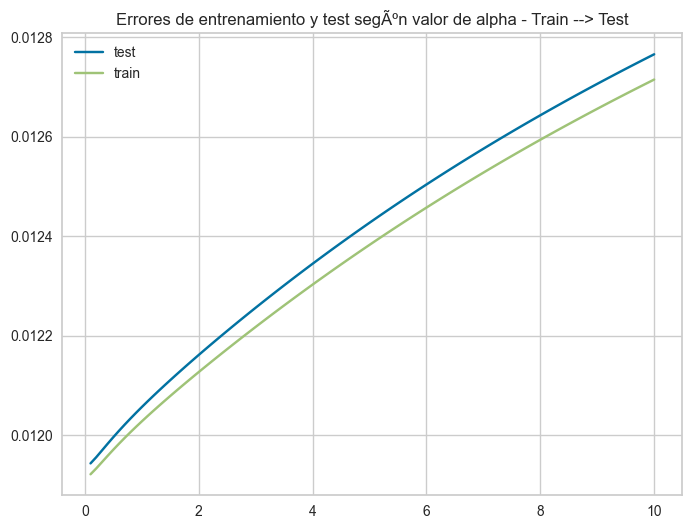

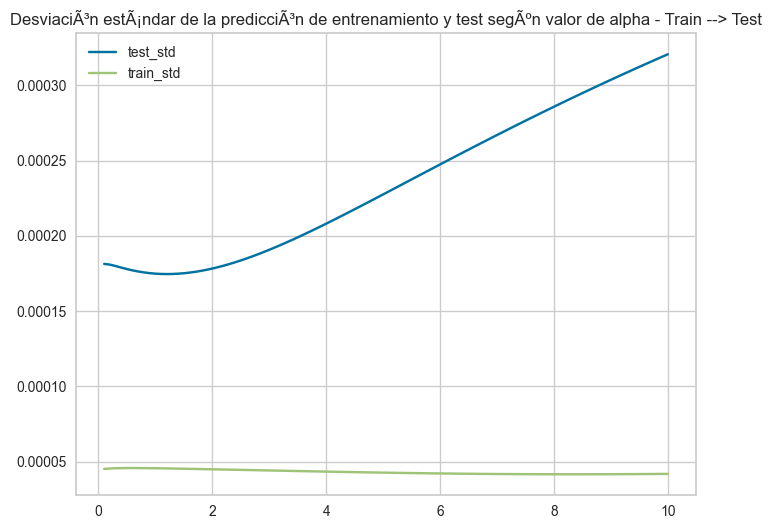

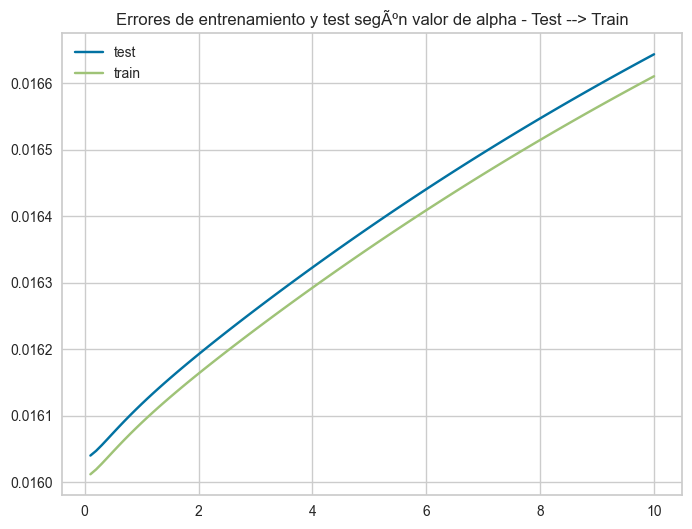

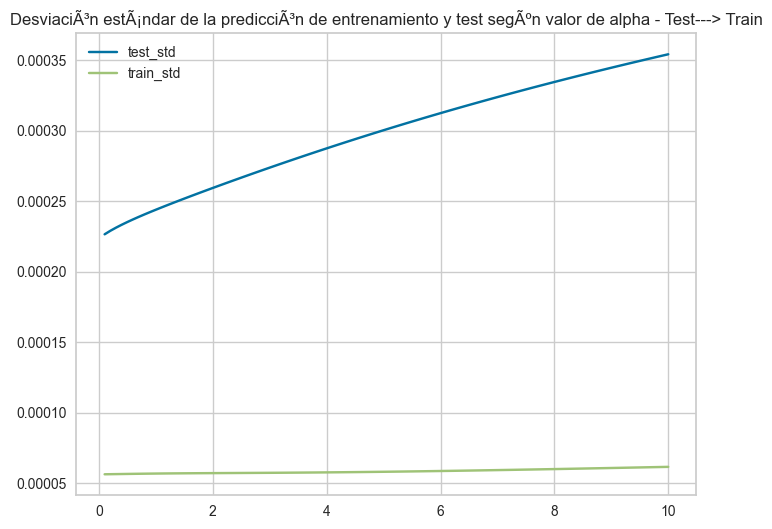

CPU times: total: 20.3 s
Wall time: 34.5 s


In [57]:
%%time
parametros1 = {'alpha':np.arange(0.1,10.1,0.1)}

X1 = base_modelo.get([x for x in base_modelo.columns if x not in ["Target"]])
y1 = base_modelo.get(["Target"]).to_numpy()

opt1, rs1, mtrain, mtest, utrain, utest, opt2, rs2, mtrain2, mtest2, utrain2, utest2 = Rigde_grid(
X=X1,Y=y1,
size_test=0.5,seed_=19042023,
parametros1 = parametros1,
metric_=RMSE,k=5,graph=True)

In [59]:
print(opt1) # modelo 1 fit train predict test
print(opt2) # modelo 2 fit test predict train

{'alpha': 0.1}
{'alpha': 0.1}


## Métricas de error modelo 1 ví­a fit train predict test

In [61]:
print("Métricas de error:")
print("RMSE train: ",mtrain)
print("RMSE test: ",mtest) 

print("Métricas de umbral:")
print("% información bien predicha train: ",utrain)
print("% información bien predicha test: ",utest)

Métricas de error:
RMSE train:  5.577471702696595
RMSE test:  3.152447580585124
Métricas de umbral:
% información bien predicha train:  98.33371450975267
% información bien predicha test:  99.54913748039729


## Métricas de error modelo 2 ví­a fit test predict train

In [62]:
print("Métricas de error:")
print("RMSE train: ",mtrain2)
print("RMSE test: ",mtest2) 

print("Métricas de umbral:")
print("% información bien predicha train: ",utrain2)
print("% información bien predicha test: ",utest2)

Métricas de error:
RMSE train:  2.7633404572445754
RMSE test:  4.525518802019324
Métricas de umbral:
% información bien predicha train:  99.82030841610037
% información bien predicha test:  99.46744208841115


## Modelo Lasso

In [63]:
def Lasso_grid(X,Y,size_test,seed_,parametros1,metric_,k,graph=True):
    X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size = size_test, 
    random_state = seed_)
    
    P1 = preprocessing.MinMaxScaler()
    P1 = P1.fit(X_train)
    P2 = preprocessing.MinMaxScaler()
    P2 = P2.fit(Y_train)
    X_train_Z = P1.transform(X_train)
    X_test_Z = P1.transform(X_test)
    Y_train_Z = P2.transform(Y_train).ravel()
    Y_test_Z = P2.transform(Y_test).ravel()
    
    modelo1 = Lasso(max_iter=10000)
    grilla1 = GridSearchCV(estimator=modelo1, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1,
    return_train_score=True)
    grilla1=grilla1.fit(X_train_Z, Y_train_Z)
    
    modelo2 = Lasso(max_iter=10000)
    grilla2 = GridSearchCV(estimator=modelo2, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1, return_train_score=True)
    grilla2=grilla2.fit(X_test_Z, Y_test_Z)
    
    res1 = pd.DataFrame(grilla1.cv_results_)
    res1 = res1.get(['param_alpha','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res1["mean_test_score"] = res1["mean_test_score"].map(abs)
    res1["mean_train_score"] = res1["mean_train_score"].map(abs)
    
    res2 = pd.DataFrame(grilla2.cv_results_)
    res2 = res2.get(['param_alpha','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res2["mean_test_score"] = res2["mean_test_score"].map(abs)
    res2["mean_train_score"] = res2["mean_train_score"].map(abs)
    
    if graph==True:
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["mean_test_score"])
        plt.plot(res1['param_alpha'],res1["mean_train_score"])
        plt.legend(['test','train'])
        plt.title("Errores de entrenamiento y test segun valor de alpha - Lasso Train --> Test")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["std_test_score"])
        plt.plot(res1['param_alpha'],res1["std_train_score"])
        plt.legend(['test_std','train_std'])
        plt.title("Desviacion estandar de la prediccion de entrenamiento y test segun valor de alpha - Lasso Train --> Test")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res2['param_alpha'],res2["mean_test_score"])
        plt.plot(res2['param_alpha'],res2["mean_train_score"])
        plt.legend(['test','train'])
        plt.title("Errores de entrenamiento y test segun valor de alpha - Lasso Test --> Train")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res2['param_alpha'],res2["std_test_score"])
        plt.plot(res2['param_alpha'],res2["std_train_score"])
        plt.legend(['test_std','train_std'])
        plt.title("Desviacion estandar de la prediccion de entrenamiento y test segun valor de alpha - Lasso Test --> Train")
        plt.show()
    
    y_hat_train_Z = grilla1.predict(X_train_Z)
    y_hat_train = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    y_hat_test_Z = grilla1.predict(X_test_Z)
    y_hat_test = P2.inverse_transform(y_hat_test_Z.reshape(-1, 1))
    
    Error_Train = metric_(Y_train,y_hat_train)
    Error_Test = metric_(Y_test,y_hat_test)
    
    Umbral_train = umbral(Y_train,y_hat_train)
    Umbral_test = umbral(Y_test,y_hat_test)
    
    y_hat_train_Z2 = grilla2.predict(X_test_Z)
    y_hat_train2 = P2.inverse_transform(y_hat_train_Z2.reshape(-1, 1))
    y_hat_test_Z2 = grilla2.predict(X_train_Z)
    y_hat_test2 = P2.inverse_transform(y_hat_test_Z2.reshape(-1, 1))
    
    Error_Train2 = metric_(Y_test,y_hat_train2)
    Error_Test2 = metric_(Y_train,y_hat_test2)
    
    Umbral_train2 = umbral(Y_test,y_hat_train2)
    Umbral_test2 = umbral(Y_train,y_hat_test2)
    
    return grilla1.best_params_, res1, Error_Train, Error_Test, Umbral_train, Umbral_test, grilla2.best_params_, res2, Error_Train2, Error_Test2, Umbral_train2, Umbral_test2


In [64]:
len(np.arange(0.1,1.1,0.1))

10

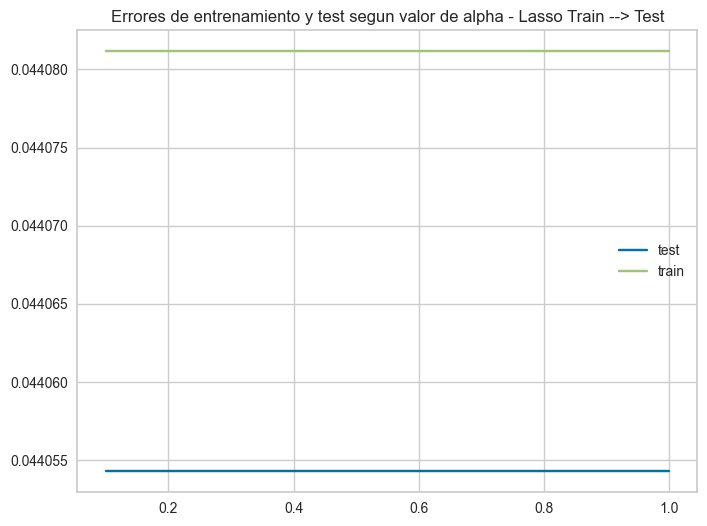

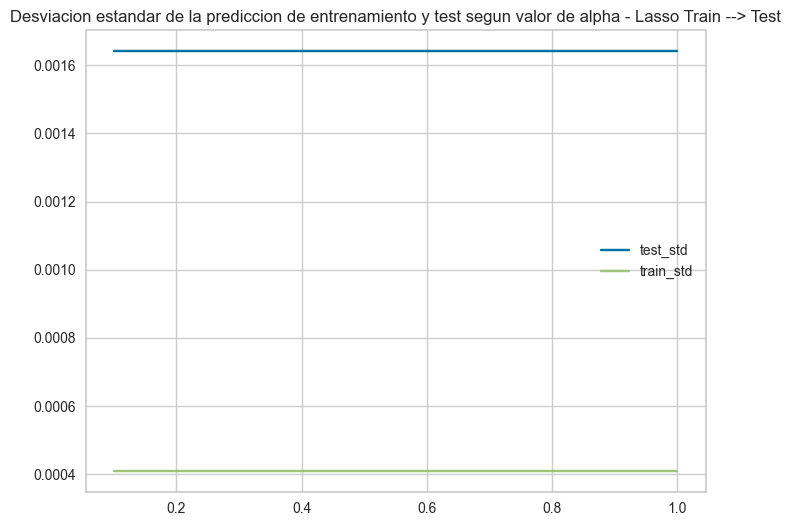

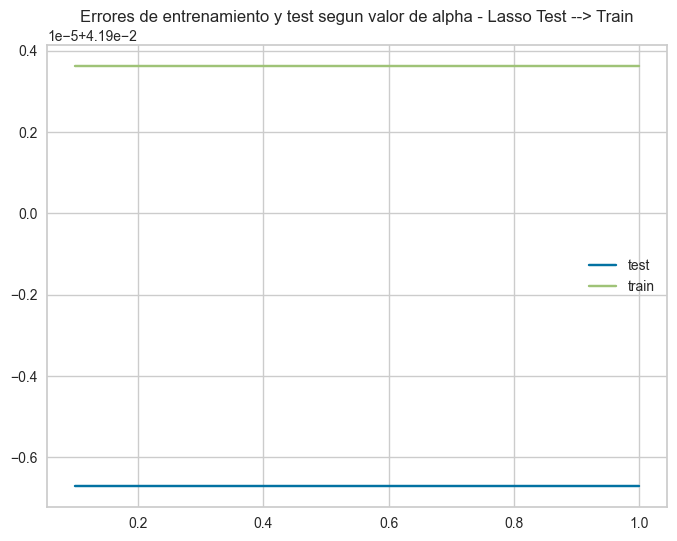

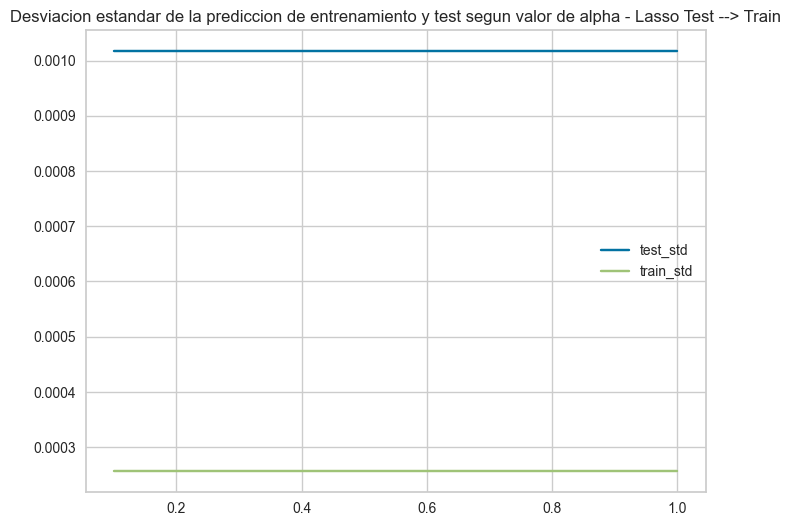

In [65]:
parametros1 = {'alpha':np.arange(0.1,1.1,0.1)}

X1 = base_modelo.get([x for x in base_modelo.columns if x not in ["Target"]])
y1 = base_modelo.get(["Target"]).to_numpy()

opt1_lasso, rs1_lasso, mtrain_lasso, mtest_lasso, utrain_lasso, utest_lasso, opt2_lasso, rs2, mtrain2_lasso, mtest2_lasso, utrain2_lasso, utest2_lasso = Lasso_grid(
X=X1,Y=y1,
size_test=0.5,seed_=19042023,
parametros1 = parametros1,
metric_=RMSE,k=5,graph=True)

In [66]:
print(opt1_lasso) # modelo 1 fit train predict test
print(opt2_lasso) # modelo 2 fit test predict train

{'alpha': 0.1}
{'alpha': 0.1}


In [69]:
print("Métricas de error:")
print("RMSE train: ",mtrain_lasso)
print("RMSE test: ",mtest_lasso) 

print("Métricas de umbral:")
print("% información bien predicha train: ",utrain_lasso)
print("% información bien predicha test: ",utest_lasso)

Métricas de error:
RMSE train:  10.252039610668122
RMSE test:  9.745945263072656
Métricas de umbral:
% información bien predicha train:  70.54922076649133
% información bien predicha test:  71.43557239937272


In [70]:
print("Métricas de error:")
print("RMSE train: ",mtrain2_lasso)
print("RMSE test: ",mtest2_lasso) 

print("Métricas de umbral:")
print("% información bien predicha train: ",utrain2_lasso)
print("% información bien predicha test: ",utest2_lasso)

Métricas de error:
RMSE train:  9.74535798358083
RMSE test:  10.252597866949328
Métricas de umbral:
% información bien predicha train:  71.5531887088343
% información bien predicha test:  70.72565099487046


## Elastic Net

In [72]:
def ElasticNet_grid(X,Y,size_test,seed_,parametros1,metric_,k,graph=True):
    X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size = size_test, 
    random_state = seed_)
    
    P1 = preprocessing.MinMaxScaler()
    P1 = P1.fit(X_train)
    P2 = preprocessing.MinMaxScaler()
    P2 = P2.fit(Y_train)
    X_train_Z = P1.transform(X_train)
    X_test_Z = P1.transform(X_test)
    Y_train_Z = P2.transform(Y_train).ravel()
    Y_test_Z = P2.transform(Y_test).ravel()
    
    modelo1 = ElasticNet(max_iter=10000)
    grilla1 = GridSearchCV(estimator=modelo1, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1,
    return_train_score=True)
    grilla1=grilla1.fit(X_train_Z, Y_train_Z)
    
    modelo2 = ElasticNet(max_iter=10000)
    grilla2 = GridSearchCV(estimator=modelo2, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1, return_train_score=True)
    grilla2=grilla2.fit(X_test_Z, Y_test_Z)
    
    res1 = pd.DataFrame(grilla1.cv_results_)
    res1 = res1.get(['param_alpha','param_l1_ratio','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res1['param_alpha'] = res1['param_alpha'].astype(float)
    res1['param_l1_ratio'] = res1['param_l1_ratio'].astype(float)
    res1['mean_test_score'] = res1['mean_test_score'].map(abs)
    res1['mean_train_score'] = res1['mean_train_score'].map(abs)
    
    res2 = pd.DataFrame(grilla2.cv_results_)
    res2 = res2.get(['param_alpha','param_l1_ratio','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res2['param_alpha'] = res2['param_alpha'].astype(float)
    res2['param_l1_ratio'] = res2['param_l1_ratio'].astype(float)
    res2['mean_test_score'] = res2['mean_test_score'].map(abs)
    res2['mean_train_score'] = res2['mean_train_score'].map(abs)
    
    if graph==True:
        fig, axes = plt.subplots(2,2, figsize=(14,10))
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_test_score'), cmap='viridis', ax=axes[0,0])
        axes[0,0].set_title('Error test - Elastic Net Train --> Test')
        axes[0,0].set_xlabel('alpha')
        axes[0,0].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_train_score'), cmap='viridis', ax=axes[0,1])
        axes[0,1].set_title('Error train - Elastic Net Train --> Test')
        axes[0,1].set_xlabel('alpha')
        axes[0,1].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='std_test_score'), cmap='magma', ax=axes[1,0])
        axes[1,0].set_title('Std test - Elastic Net Train --> Test')
        axes[1,0].set_xlabel('alpha')
        axes[1,0].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='std_train_score'), cmap='magma', ax=axes[1,1])
        axes[1,1].set_title('Std train - Elastic Net Train --> Test')
        axes[1,1].set_xlabel('alpha')
        axes[1,1].set_ylabel('l1_ratio')
        plt.tight_layout()
        plt.show()
        
        fig, axes = plt.subplots(2,2, figsize=(14,10))
        sns.heatmap(res2.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_test_score'), cmap='viridis', ax=axes[0,0])
        axes[0,0].set_title('Error test - Elastic Net Test --> Train')
        axes[0,0].set_xlabel('alpha')
        axes[0,0].set_ylabel('l1_ratio')
        sns.heatmap(res2.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_train_score'), cmap='viridis', ax=axes[0,1])
        axes[0,1].set_title('Error train - Elastic Net Test --> Train')
        axes[0,1].set_xlabel('alpha')
        axes[0,1].set_ylabel('l1_ratio')
        sns.heatmap(res2.pivot(index='param_l1_ratio', columns='param_alpha', values='std_test_score'), cmap='magma', ax=axes[1,0])
        axes[1,0].set_title('Std test - Elastic Net Test --> Train')
        axes[1,0].set_xlabel('alpha')
        axes[1,0].set_ylabel('l1_ratio')
        sns.heatmap(res2.pivot(index='param_l1_ratio', columns='param_alpha', values='std_train_score'), cmap='magma', ax=axes[1,1])
        axes[1,1].set_title('Std train - Elastic Net Test --> Train')
        axes[1,1].set_xlabel('alpha')
        axes[1,1].set_ylabel('l1_ratio')
        plt.tight_layout()
        plt.show()
    
    y_hat_train_Z = grilla1.predict(X_train_Z)
    y_hat_train = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    y_hat_test_Z = grilla1.predict(X_test_Z)
    y_hat_test = P2.inverse_transform(y_hat_test_Z.reshape(-1, 1))
    
    Error_Train = metric_(Y_train,y_hat_train)
    Error_Test = metric_(Y_test,y_hat_test)
    
    Umbral_train = umbral(Y_train,y_hat_train)
    Umbral_test = umbral(Y_test,y_hat_test)
    
    y_hat_train_Z2 = grilla2.predict(X_test_Z)
    y_hat_train2 = P2.inverse_transform(y_hat_train_Z2.reshape(-1, 1))
    y_hat_test_Z2 = grilla2.predict(X_train_Z)
    y_hat_test2 = P2.inverse_transform(y_hat_test_Z2.reshape(-1, 1))
    
    Error_Train2 = metric_(Y_test,y_hat_train2)
    Error_Test2 = metric_(Y_train,y_hat_test2)
    
    Umbral_train2 = umbral(Y_test,y_hat_train2)
    Umbral_test2 = umbral(Y_train,y_hat_test2)
    
    return grilla1.best_params_, res1, Error_Train, Error_Test, Umbral_train, Umbral_test, grilla2.best_params_, res2, Error_Train2, Error_Test2, Umbral_train2, Umbral_test2

def ElasticNet_grid_completed(X,Y,parametros1,metric_,k,graph=True):
    P1 = preprocessing.MinMaxScaler()
    P1 = P1.fit(X)
    P2 = preprocessing.MinMaxScaler()
    P2 = P2.fit(Y)
    X_train_Z = P1.fit_transform(X)
    Y_train_Z = P2.fit_transform(Y).ravel()
    
    modelo1 = ElasticNet(max_iter=10000)
    grilla1 = GridSearchCV(estimator=modelo1, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1, return_train_score=True)
    grilla1=grilla1.fit(X_train_Z, Y_train_Z)
    
    res1 = pd.DataFrame(grilla1.cv_results_)
    res1 = res1.get(['param_alpha','param_l1_ratio','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res1['param_alpha'] = res1['param_alpha'].astype(float)
    res1['param_l1_ratio'] = res1['param_l1_ratio'].astype(float)
    res1['mean_test_score'] = res1['mean_test_score'].map(abs)
    res1['mean_train_score'] = res1['mean_train_score'].map(abs)
    
    if graph==True:
        fig, axes = plt.subplots(2,2, figsize=(14,10))
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_test_score'), cmap='viridis', ax=axes[0,0])
        axes[0,0].set_title('Error test - Elastic Net Train --> Test')
        axes[0,0].set_xlabel('alpha')
        axes[0,0].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_train_score'), cmap='viridis', ax=axes[0,1])
        axes[0,1].set_title('Error train - Elastic Net Train --> Test')
        axes[0,1].set_xlabel('alpha')
        axes[0,1].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='std_test_score'), cmap='magma', ax=axes[1,0])
        axes[1,0].set_title('Std test - Elastic Net Train --> Test')
        axes[1,0].set_xlabel('alpha')
        axes[1,0].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='std_train_score'), cmap='magma', ax=axes[1,1])
        axes[1,1].set_title('Std train - Elastic Net Train --> Test')
        axes[1,1].set_xlabel('alpha')
        axes[1,1].set_ylabel('l1_ratio')
        plt.tight_layout()
        plt.show()
    
    y_hat_train_Z = grilla1.predict(X_train_Z)
    y_hat_train = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    
    Error_Train = metric_(Y,y_hat_train)
    Umbral_train = umbral(Y,y_hat_train)
    
    return grilla1, grilla1.best_params_, res1, Error_Train, Umbral_train, P1, P2


In [73]:
len(np.arange(0.2,5.2,0.2)) # lambda libro (alpha)

25

In [74]:
len(np.arange(0.2,1.2,0.2)) # alpha (l1_ratio)

5

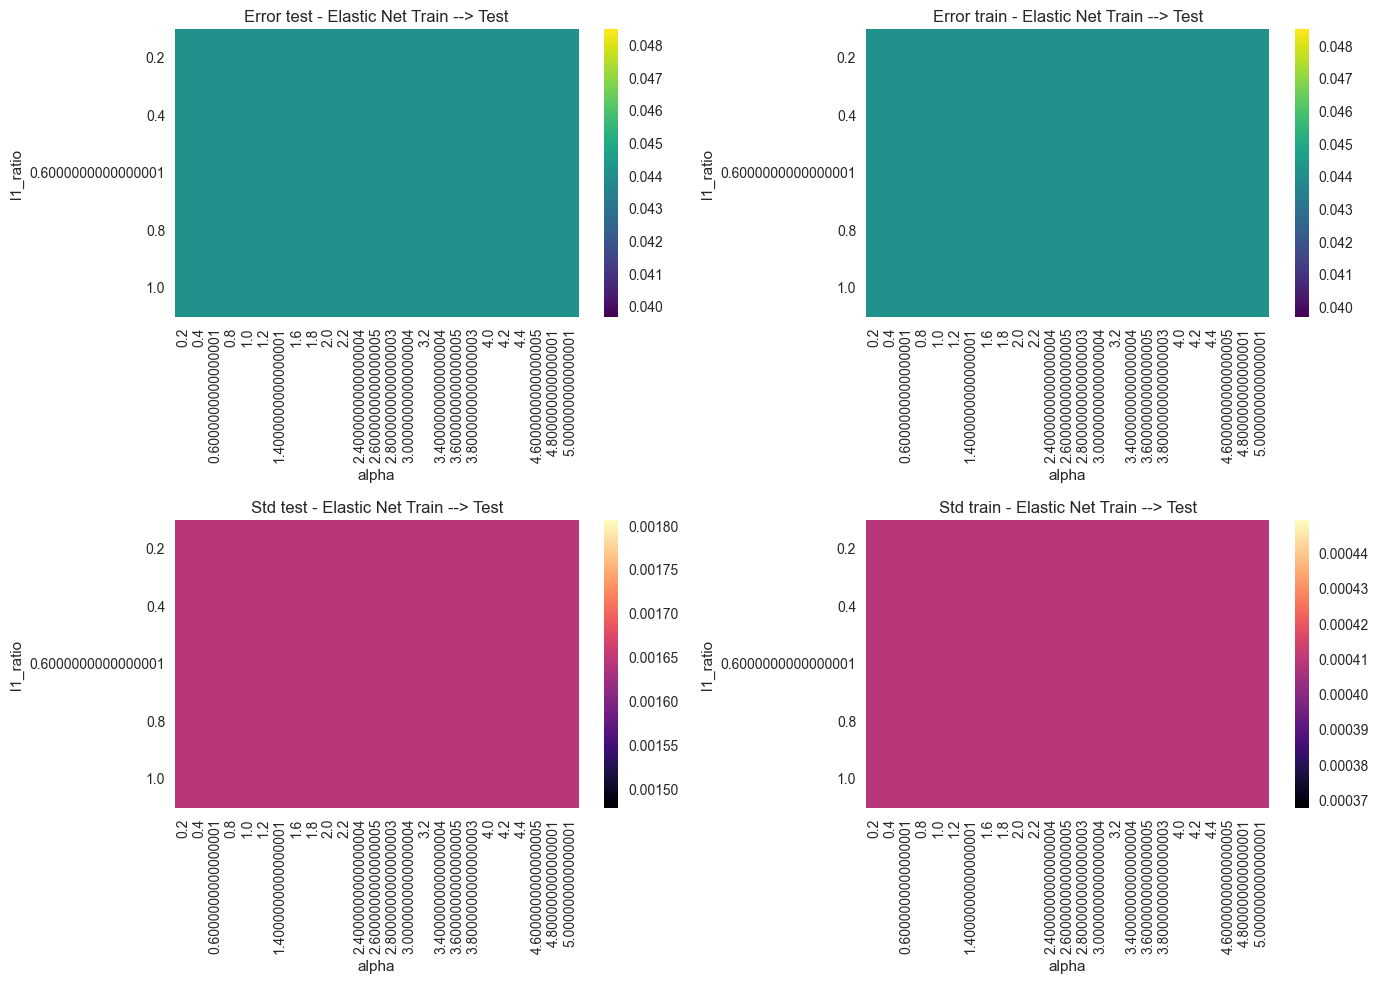

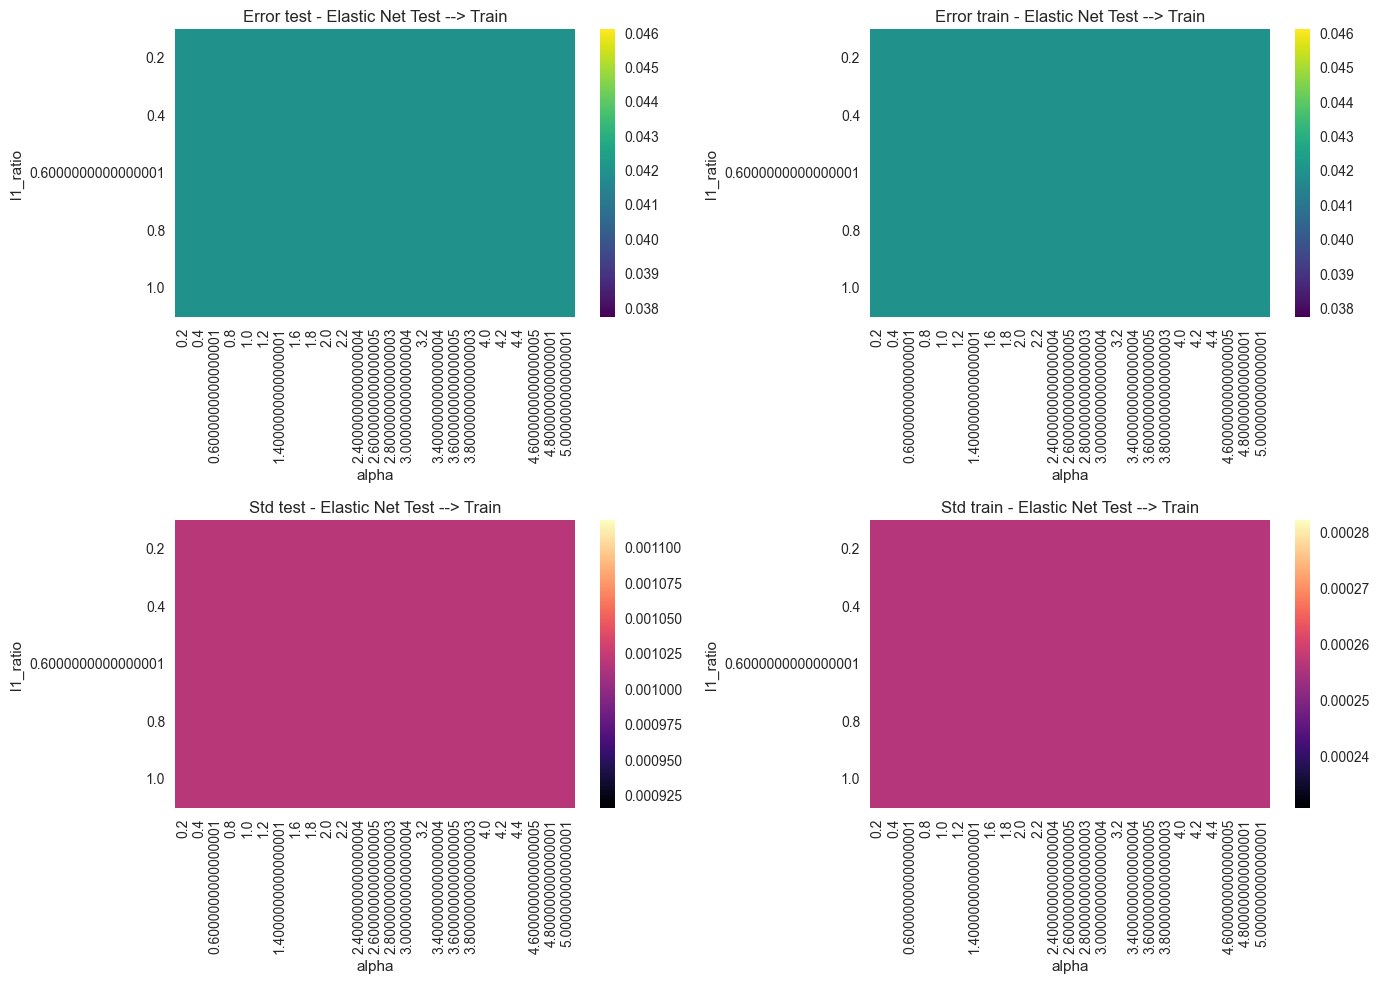

CPU times: total: 39.7 s
Wall time: 1min 8s


In [75]:
%%time
parametros1 = {'alpha':np.arange(0.2,5.2,0.2), 'l1_ratio':np.arange(0.2,1.2,0.2)}

X1 = base_modelo.get([x for x in base_modelo.columns if x not in ["Target"]])
y1 = base_modelo.get(["Target"]).to_numpy()

opt1_elastic, rs1_elastic, mtrain_elastic, mtest_elastic, utrain_elastic, utest_elastic, opt2_elastic, rs2_elastic, mtrain2_elastic, mtest2_elastic, utrain2_elastic, utest2_elastic = ElasticNet_grid(
X=X1,Y=y1,
size_test=0.5,seed_=19042023,
parametros1 = parametros1,
metric_=RMSE,k=5,graph=True)

In [67]:
print(opt1_elastic) # modelo 1 fit train predict test
print(opt2_elastic) # modelo 2 fit test predict train

{'alpha': 0.2, 'l1_ratio': 0.2}
{'alpha': 0.2, 'l1_ratio': 0.2}


In [76]:
print("Métricas de error:")
print("Train RMSE: ",mtrain_elastic)
print("Test RMSE: ",mtest_elastic)

print("Métricas de umbral:")
print("% bien predicha train: ",utrain_elastic)
print("% bien predicha test: ",utest_elastic)

Métricas de error:
Train RMSE:  10.252039610668122
Test RMSE:  9.745945263072656
Métricas de umbral:
% bien predicha train:  70.54922076649133
% bien predicha test:  71.43557239937272


In [77]:
print("Métricas de error:")
print("Train RMSE: ",mtrain2_elastic)
print("Test RMSE: ",mtest2_elastic)

print("Métricas de umbral:")
print("% bien predicha train: ",utrain2_elastic)
print("% bien predicha test: ",utest2_elastic)

Métricas de error:
Train RMSE:  9.74535798358083
Test RMSE:  10.252597866949328
Métricas de umbral:
% bien predicha train:  71.5531887088343
% bien predicha test:  70.72565099487046


## Comparación de modelos

### vía fit train predict test

In [78]:
pd.DataFrame({'modelo':["Ridge","Lasso","Elastic Net"], 'Error Train':[mtrain,mtrain_lasso,mtrain_elastic], 'Error Test':[mtest,mtest_lasso,mtest_elastic], 'Umbral Train':[utrain,utrain_lasso,utrain_elastic], 'Umbral Test':[utest,utest_lasso,utest_elastic]})

,modelo,Error Train,Error Test,Umbral Train,Umbral Test
0,Ridge,5.577472,3.152448,98.333715,99.549137
1,Lasso,10.252040,9.745945,70.549221,71.435572
2,Elastic Net,10.252040,9.745945,70.549221,71.435572


### vía fit test predict train

In [79]:
pd.DataFrame({'modelo':["Ridge","Lasso","Elastic Net"], 'Error Train':[mtrain2,mtrain2_lasso,mtrain2_elastic], 'Error Test':[mtest2,mtest2_lasso,mtest2_elastic], 'Umbral Train':[utrain2,utrain2_lasso,utrain2_elastic], 'Umbral Test':[utest2,utest2_lasso,utest2_elastic]})

,modelo,Error Train,Error Test,Umbral Train,Umbral Test
0,Ridge,2.763340,4.525519,99.820308,99.467442
1,Lasso,9.745358,10.252598,71.553189,70.725651
2,Elastic Net,9.745358,10.252598,71.553189,70.725651


## Entrenamiento del mejor modelo completo

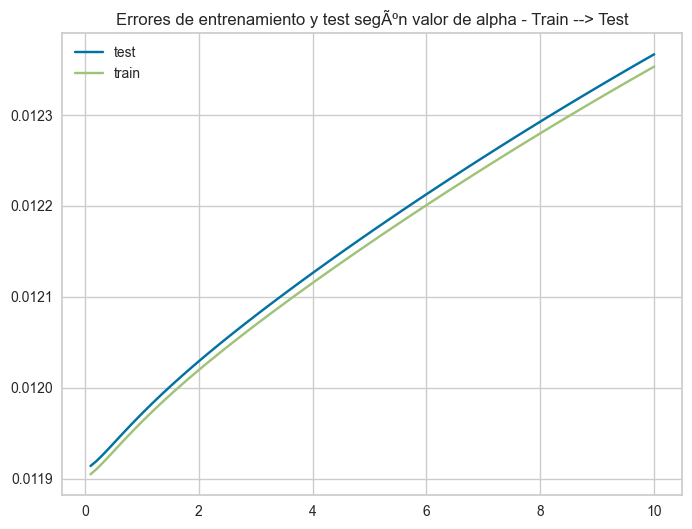

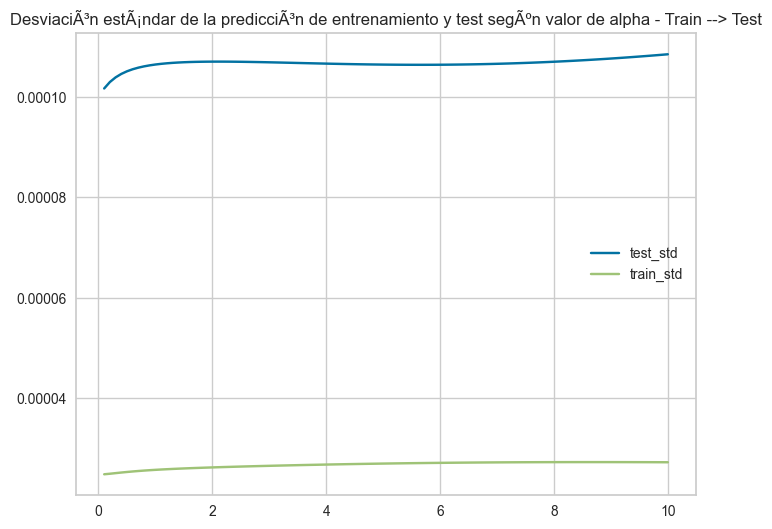

CPU times: total: 11.5 s
Wall time: 23.4 s


In [80]:
%%time
parametros1 = {'alpha':np.arange(0.1,10.1,0.1)}
modelo1, opt, r1, mtrain1, mumbral1, trans1, trans2 = Rigde_grid_completed(
X=X1,Y=y1,
parametros1=parametros1,metric_=RMSE,k=5,graph=True)

In [81]:
print(mtrain1)
print(mumbral1)

2.768628462488031
99.81703830760435


In [82]:
path2 = "C:/Users/Alber/OneDrive/Documentos/Métodos Supervisados USTA 2026/módulo 1/code 3/"

In [83]:
import pickle
with open(path2 + 'best_model_Ridge.pkl', 'wb') as model_file:
    pickle.dump(modelo1, model_file)

## Predicción nuevos datos

In [84]:
prueba.head(2)

,id,Marital status,Course,Previous qualification,Mothers qualification,Fathers qualification,Admission grade,Displaced,Educational special needs,Gender,...,Curricular units 2nd sem credited,Curricular units 2nd sem enrolled,Curricular units 2nd sem evaluations,Curricular units 2nd sem approved,Curricular units 2nd sem grade,Curricular units 2nd sem without evaluations,Unemployment rate,Inflation rate,GDP,Target
0,1,E1,9238,1,19,19,119.8,E1,E0,E0,...,0,6,9,0,0.00,0,11.1,0.6,2.02,47.711099
1,3,E1,9500,1,19,3,126.1,E1,E0,E0,...,0,8,11,7,12.82,0,11.1,0.6,2.02,63.585995


In [85]:
cuantitativas

['Course',
 'Previous qualification',
 'Mothers qualification',
 'Fathers qualification',
 'Admission grade',
 'Age at enrollment',
 'Curricular units 1st sem credited',
 'Curricular units 1st sem enrolled',
 'Curricular units 1st sem evaluations',
 'Curricular units 1st sem approved',
 'Curricular units 1st sem grade ',
 'Curricular units 1st sem without evaluations',
 'Curricular units 2nd sem credited ',
 'Curricular units 2nd sem enrolled ',
 'Curricular units 2nd sem evaluations',
 'Curricular units 2nd sem approved',
 'Curricular units 2nd sem grade',
 'Curricular units 2nd sem without evaluations',
 'Unemployment rate',
 'Inflation rate',
 'GDP']

In [86]:
categoricas

['Marital status', 'Displaced', 'Educational special needs', 'Gender']

In [87]:
# Variables cuantitativas (Activar D1)
D1 = prueba.get(cuantitativas).copy()

# Variables categÃ³ricas
D2 = prueba.get(categoricas).copy()
for k in categoricas:
  D2[k] = D2[k].map(nombre_)
D4 = D2.copy()

# Variables al cuadrado (Activar D1)
cuadrado = [re.findall(r'(.+)_\d+', item) for item in c2]
cuadrado = [x[0] for x in cuadrado]

for k in cuadrado:
  D1[k+"_2"] = D1[k] ** 2

# Interacciones cuantitativas (Activar D1)
result = [re.findall(r'([A-Za-z\s\(\)0-9]+)', item) for item in cxy]

for k in result:
  D1[k[0]+"__"+k[1]] = D1[k[0]] * D1[k[1]]

# Razones
result2 = [re.findall(r'(.+)__coc__(.+)', item) for item in razxy]
for k in result2:
  k2 = k[0]
  D1[k2[0]+"__coc__"+k2[1]] = D1[k2[0]] / (D1[k2[1]]+0.01)

# Interacciones categÃ³ricas
result3 = [re.search(r'([^_]+__[^_]+)', item).group(1).split('__') for item in catxy]
for k in result3:
  D4[k[0]+"__"+k[1]] = D4[k[0]] + "_" + D4[k[1]]

# InteracciÃ³n cuantitativa vs categÃ³rica
D5 = prueba.copy()
result4 = [re.search(r'(.+?)_(.+?)_E\d+', item).groups() for item in cuactxy]
contador = 0
for k in result4:
  col1, col2 = k[1], k[0] # categÃ³rica, cuantitativa
  if contador == 0:
    D51 = pd.get_dummies(D5[col1],drop_first=True)
    for j in D51.columns:
      D51[j] = D51[j] * D5[col2]
    D51.columns = [col2+"_"+col1+"_"+ str(x) for x in D51.columns]
  else:
    D52 = pd.get_dummies(D5[col1],drop_first=True)
    for j in D52.columns:
      D52[j] = D52[j] * D5[col2]
    D52.columns = [col2+"_"+col1+"_"+ str(x) for x in D52.columns]
    D51 = pd.concat([D51,D52],axis=1)
  contador = contador + 1

In [88]:
B1 = pd.concat([D1,D4],axis=1)
base_modelo_prueba = pd.concat([B1,D51],axis=1)
base_modelo_prueba.head(3)

,Course,Previous qualification,Mothers qualification,Fathers qualification,Admission grade,Age at enrollment,Curricular units 1st sem credited,Curricular units 1st sem enrolled,Curricular units 1st sem evaluations,Curricular units 1st sem approved,...,Educational special needs__Gender,Marital status__Displaced,Marital status__Educational special needs,Curricular units 1st sem approved_Gender_E1,Curricular units 1st sem enrolled_Gender_E1,Curricular units 1st sem approved_Marital status_E2,Curricular units 1st sem approved_Marital status_E3,Curricular units 1st sem approved_Marital status_E4,Curricular units 1st sem approved_Marital status_E5,Curricular units 1st sem approved_Marital status_E6
0,9238,1,19,19,119.8,18,0,6,8,4,...,CE0_CE0,CE1_CE1,CE1_CE0,0,0,0,0,0,0,0
1,9500,1,19,3,126.1,18,0,7,9,7,...,CE0_CE0,CE1_CE1,CE1_CE0,0,0,0,0,0,0,0
2,171,19,19,19,100.0,24,0,0,0,0,...,CE0_CE1,CE1_CE0,CE1_CE0,0,0,0,0,0,0,0


In [89]:
len(base_modelo_prueba.columns) # TEST : 44 variables

44

In [91]:
len(base_modelo.columns) # TRAIN : 45 (44 covariables + target)

45

In [92]:
columnas_object = [
    "Marital status",
    "Displaced",
    "Educational special needs",
    "Gender",
    "Educational special needs__Gender",
    "Marital status__Displaced",
    "Marital status__Educational special needs"
]


for col in columnas_object:
    base_modelo_prueba[col] = transformadores_label[col].transform(base_modelo_prueba[col])

base_modelo_prueba[columnas_object].head()

,Marital status,Displaced,Educational special needs,Gender,Educational special needs__Gender,Marital status__Displaced,Marital status__Educational special needs
0,0,1,0,0,0,1,0
1,0,1,0,0,0,1,0
2,0,0,0,1,1,0,0
3,0,0,0,1,1,0,0
4,0,0,0,0,0,0,0


## Pronóstico

In [93]:
Z1 = trans1
Z2 = trans2

X_prueba_z = Z1.transform(base_modelo_prueba)
y_prueba_pred_z = modelo1.predict(X_prueba_z)
y_prueba_pred = Z2.inverse_transform(np.array(y_prueba_pred_z).reshape(-1, 1)).ravel()

## Performance / Backtesting / Monitoreo

In [94]:
RMSE(prueba["Target"], y_prueba_pred)

2.7965569973812046

In [95]:
umbral(prueba["Target"], y_prueba_pred,umbral = param_umbral)

99.79089067503104

## Conclusiones / Informe
obtuvimos .....